Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Number Participants: 39
 Participant  S1_QA  S1_QB  S1_QC  S1_QD  S2_QA  S2_QC  S2_QD  S3_QA  S3_QB  S3_QD  S4_QA  S4_QB  S4_QC  S4_QD  S5_QA  S5_QB  S5_QC  S5_QD  S2_QB  S3_QC
           2      0      0      2      0      0      0      0      0      0      2      0      0      0      0      0      0      1      2      0      0
           3      2      2      2      2      2      2      2      2      2      2      2      1      2      1      2      2      2      2      1      1
           4      2      2      0      0      0      0      2      0      0      0      0      0      1      0      0      0      2      2      0      1
           5      0      2      0      0      0      0      0      0      0      0      0      0      1      2      2      0      1      2      1      1
           6      0      0      2      1      2      2      2      0      2      2

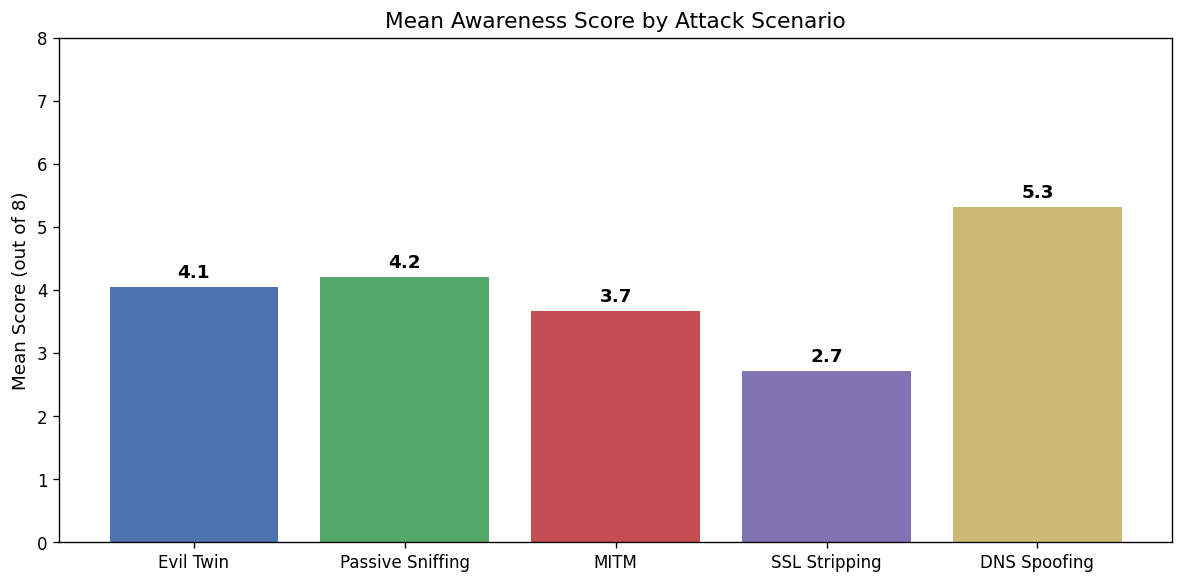

In [26]:

from google.colab import files
from google.colab import drive
drive.mount('/content/drive')
file = '/content/drive/MyDrive/Spring_2026/CMPT_479/data.xlsx'

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns

#CMPT 479 Project Survey Part2 Score Calculation

data = pd.read_excel(file, header=None)
row = data.iloc[2:].reset_index(drop=True)
n = len(row) #number participants in survey
print(f"Number Participants: {n}")

#all questions except for S2QB and S3QB are single select survey answers
#scoring single select questions, points are correlated to survey part2 doc

single_select_score = {

    #scenario 1 evil twin, 102 is first col with P2 survey data in wifi_data.xlsx
    'S1_QA': {102: 0, 103: 0, 104: 1, 105: 2, 106: 2},
    'S1_QB': {107: 0, 108: 0, 109: 0, 110: 0, 111: 2},
    'S1_QC': {112: 0, 113: 0, 114: 2, 115: 0, 116: 1},
    'S1_QD': {117: 0, 118: 0, 119: 1, 120: 1, 121: 2},

    #scenario 2 passive sniff
    'S2_QA': {122: 0, 123: 0, 124: 1, 125: 2, 126: 1},
    # S2_QB handled separately
    'S2_QC': {132: 0, 133: 0, 134: 1, 135: 2, 136: 0},
    'S2_QD': {137: 0, 138: 0, 139: 1, 140: 2},

    #s3 MITM
    'S3_QA': {141: 0, 142: 0, 143: 0, 144: 2, 145: 0},
    'S3_QB': {146: 0, 147: 0, 148: 0, 149: 2, 150: 1},
    # S3_QC handled separtely
    'S3_QD': {157: 2, 158: 0, 159: 0, 160: 0, 161: 1},

    #s4 ssl stripping
    'S4_QA': {162: 0, 163: 1, 164: 2, 165: 0, 166: 0},
    'S4_QB': {167: 0, 168: 2, 169: 0, 170: 0, 171: 1},
    'S4_QC': {172: 0, 173: 1, 174: 2, 175: 0, 176: 0},
    'S4_QD': {177: 0, 178: 0, 179: 2, 180: 0, 181: 1},

    #s5 dns spoofing
    'S5_QA': {182: 0, 183: 0, 184: 0, 185: 2, 186: 0},
    'S5_QB': {187: 0, 188: 0, 189: 2, 190: 0, 191: 1},
    'S5_QC': {192: 1, 193: 2, 194: 1, 195: 0, 196: 0},
    'S5_QD': {197: 0, 198: 2, 199: 0, 200: 0, 201: 2},
}

#questions handled separately
s2_qb_cols = {
    127: 'correct',    # which websites I'm visiting
    128: 'correct',    # my passwords if the website doesn't use encryption
    129: 'neutral',    # i'm not sure
    130: 'incorrect',  # everything, even for encrypted sites
    131: 'incorrect',  # nothing, because my phone handles the security automatically
}

s3_qc_cols = {
    151: 'correct',    # using a VPN
    152: 'correct',    # only using sites with the lock icon
    153: 'incorrect',  # using private/incognito mode on browsers
    154: 'incorrect',  # making sure the WiFi has a password
    155: 'incorrect',  # turning off Bluetooth
    156: 'neutral',    # i'm not sure what would help
}

def score_single_select(row, col_score_mtx):
    for col, score in col_score_mtx.items():
      if pd.notna(row.iloc[col]):
        return score
    return 0


def score_s2_qb(row):
  # 0 correct == 0, 1 correct == 1, 2+ correct (no incorrect) == 2
  # if correct items selected alongside incorrect items, cap at 1 (not subtract)
  has_inc = any(pd.notna(row.iloc[c]) for c, t in s2_qb_cols.items() if t == 'incorrect')
  corr = sum(1 for c, t in s2_qb_cols.items() if t == 'correct' and pd.notna(row.iloc[c]))
  if corr == 0:
    return 0
  if has_inc:
    return 1
  return min(corr, 2)

def score_s3_qc(row):
  # 0 correct == 0, 1 correct == 1, 2+ correct == 2
  inc  = sum(1 for c, t in s3_qc_cols.items() if t == 'incorrect' and pd.notna(row.iloc[c]))
  corr = sum(1 for c, t in s3_qc_cols.items() if t == 'correct' and pd.notna(row.iloc[c]))
  base = min(corr, 2)
  score = base - inc
  return max(0, min(2, score))


def score_section(score):
  if score <= 2:
    return 'Unaware'
  elif score <= 4:
    return 'Partially Aware'
  elif score <= 6:
    return 'Mostly Aware'
  else:
    return 'Fully Aware'

#classify overall participant score
def score_total(score):
  if score <= 10:
    return 'Unaware'
  elif score <= 20:
    return 'Partially Aware'
  elif score <= 30:
    return 'Mostly Aware'
  else:
    return 'Fully Aware'

results = []

for i in range(n):
  row_num = data.iloc[i+2]
  r = {'Participant': i+2}
  for qname, col_map in single_select_score.items():
    r[qname] = score_single_select(row_num, col_map)

  r['S2_QB'] = score_s2_qb(row_num)
  r['S3_QC'] = score_s3_qc(row_num)

  r['S1_Total'] = r['S1_QA'] + r['S1_QB'] + r['S1_QC'] + r['S1_QD']
  r['S2_Total'] = r['S2_QA'] + r['S2_QB'] + r['S2_QC'] + r['S2_QD']
  r['S3_Total'] = r['S3_QA'] + r['S3_QB'] + r['S3_QC'] + r['S3_QD']
  r['S4_Total'] = r['S4_QA'] + r['S4_QB'] + r['S4_QC'] + r['S4_QD']
  r['S5_Total'] = r['S5_QA'] + r['S5_QB'] + r['S5_QC'] + r['S5_QD']

  #overall score
  r['Overall_Score'] = r['S1_Total'] + r['S2_Total'] + r['S3_Total'] + r['S4_Total'] + r['S5_Total']


  r['S1_Tier'] = score_section(r['S1_Total'])
  r['S2_Tier'] = score_section(r['S2_Total'])
  r['S3_Tier'] = score_section(r['S3_Total'])
  r['S4_Tier'] = score_section(r['S4_Total'])
  r['S5_Tier'] = score_section(r['S5_Total'])
  r['Overall_Tier'] = score_total(r['Overall_Score'])

  results.append(r)

df_res = pd.DataFrame(results)

#display results
q_cols = [c for c in df_res.columns if c.startswith('S') and '_Q' in c]

#individual score
print(df_res[['Participant'] + q_cols].to_string(index=False))

#stats
section_cols = ['Participant', 'S1_Total', 'S1_Tier', 'S2_Total', 'S2_Tier',
                'S3_Total', 'S3_Tier', 'S4_Total', 'S4_Tier',
                'S5_Total', 'S5_Tier', 'Overall_Score', 'Overall_Tier']

print(df_res[section_cols].to_string(index=False))

for s in ['S1_Total', 'S2_Total', 'S3_Total', 'S4_Total', 'S5_Total', 'Overall_Score']:
    vals = df_res[s]
    label = s.replace('_Total', '')
    max_pts = 8 if 'S' in label and label != 'Overall' else 40
    print(f"{label:>8}: mean={vals.mean():.2f}/{max_pts}  median={vals.median():.1f}  "
          f"min={vals.min()}  max={vals.max()}  std={vals.std():.2f}")

#tiers
#print(df_res['Overall_Score'].value_counts().to_string())
print("\n\n")
print(df_res['Overall_Tier'].value_counts().sort_index().to_string())

matplotlib.rcParams['figure.dpi'] = 120

# extracting part1 data and cross referencing with part 2 data
def extract_single_select(row, col_score_map):
    #extracting value from the non-empty cell
    for col, val in col_score_map.items():
        if pd.notna(row.iloc[col]):
            return val

def extract_multi_select(row, col_label_map):
    return [label for col, label in col_label_map.items() if pd.notna(row.iloc[col])]

#participant profiles
profiles = []
for i in range(n):
    row = data.iloc[i + 2]
    p = {'Participant': i + 2}

    #demographics
    p['Age'] = extract_single_select(row, {11:'18-24', 12:'25-34', 13:'35-44', 14:'45-54', 15:'55+'})
    p['Field'] = extract_single_select(row, {
        16:'Tech/IT/SW/Eng', 17:'Business/Finance', 18:'Healthcare',
        19:'Education', 20:'Sciences', 21:'Arts/Media/Design',
        22:'Trades/Labour', 23:'Other'
    })
    p['Tech_Experience'] = extract_single_select(row, {
        24:'Direct tech', 25:'Regular user', 26:'Occasional', 27:'Minimal', 28:'Other'
    })

    # 1-5 scale
    p['Tech_Knowledge'] = extract_single_select(row, {29:1, 30:2, 31:3, 32:4, 33:5})
    p['WiFi_Familiarity'] = extract_single_select(row, {34:1, 35:2, 36:3, 37:4, 38:5})

    # wifi usage habits
    p['WiFi_Frequency'] = extract_single_select(row, {39:'Never', 40:'Rarely', 41:'Sometimes', 42:'Frequently'})

    # user perceptions/attitude
    p['Security_Concern'] = extract_single_select(row, {62:1, 63:2, 64:3, 65:4, 66:5})
    p['WiFi_Attitude'] = extract_single_select(row, {
        67:"Don't think about it", 68:'Assume mostly safe',
        69:'Somewhat cautious', 70:'Actively take precautions',
        71:'Avoid public WiFi'
    })
    p['Bad_Experience'] = extract_single_select(row, {72:'Yes', 73:'No'})

    # do they practise security
    p['Knows_VPN'] = extract_single_select(row, {75:'Yes', 76:'No', 77:'Heard of it'})
    p['VPN_Usage'] = extract_single_select(row, {78:'Never', 79:'Rarely', 80:'Sometimes', 81:'Usually', 82:'Always', 83:'N/A'})
    p['HTTP_Attention'] = extract_single_select(row, {84:'Yes', 85:'No', 86:'Sometimes', 87:"Don't know difference"})

    # self-reported awareness
    p['Aware_of_Threats'] = extract_single_select(row, {92:'Yes', 93:'Somewhat', 94:'No'})

    # specific attacks participants heard of
    heard = extract_multi_select(row, {96:'None', 97:'MITM', 98:'Evil Twin', 99:'Packet Sniffing', 100:'DNS Spoofing', 101:'SSL Stripping'})

    p['Heard_MITM'] = 'MITM' in heard
    p['Heard_EvilTwin'] = 'Evil Twin' in heard
    p['Heard_Sniffing'] = 'Packet Sniffing' in heard
    p['Heard_DNS'] = 'DNS Spoofing' in heard
    p['Heard_SSL'] = 'SSL Stripping' in heard
    p['Heard_None'] = 'None' in heard
    p['Attacks_Heard_Count'] = sum([p['Heard_MITM'], p['Heard_EvilTwin'], p['Heard_Sniffing'], p['Heard_DNS'], p['Heard_SSL']])

    profiles.append(p)

df_profiles = pd.DataFrame(profiles)



# merging profiles with scores
df = df_res.merge(df_profiles, on='Participant')
print(f"Combined dataset: {len(df)} participants × {len(df.columns)} columns\n")


######### Scenario awareness scores:
print("\n\nUser Awareness Per Scenario\n\n")
scenario_names = {'S1': 'Evil Twin', 'S2': 'Passive Sniffing', 'S3': 'MITM', 'S4': 'SSL Stripping', 'S5': 'DNS Spoofing'}

for s, name in scenario_names.items():
    total_col = f'{s}_Total'
    tier_col = f'{s}_Tier'
    print(f"\n--- {name} ({s}) ---")
    print(f"  Mean: {df[total_col].mean():.2f}/8  |  Median: {df[total_col].median():.1f}")
    print(f"  Tier distribution:")
    for tier in ['Unaware', 'Partially Aware', 'Mostly Aware', 'Fully Aware']:
        count = (df[tier_col] == tier).sum()
        pct = count / len(df) * 100
        print(f"    {tier:>16}: {count:2d} ({pct:5.1f}%)")

fig, ax = plt.subplots(figsize=(10, 5))
section_means = [df[f'{s}_Total'].mean() for s in scenario_names]
bars = ax.bar(list(scenario_names.values()), section_means, color=['#4C72B0','#55A868','#C44E52','#8172B2','#CCB974'])
ax.set_ylabel('Mean Score (out of 8)')
ax.set_title('Mean Awareness Score by Attack Scenario')
ax.set_ylim(0, 8)
for bar, val in zip(bars, section_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15, f'{val:.1f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()




Self-Reported Tech Knowledge vs Actual Scores



Tech Knowledge = 1 (Very Low) : n=1
Overall mean: 16.0/40  |  Tier(s): Partially Aware

Tech Knowledge = 2 (Low) : n=5
Overall mean: 16.2/40  |  Tier(s): Partially Aware, Mostly Aware, Partially Aware, Partially Aware, Partially Aware

Tech Knowledge = 3 (Moderate) : n=16
Overall mean: 18.8/40  |  Tier(s): Partially Aware, Mostly Aware, Partially Aware, Partially Aware, Unaware, Fully Aware, Mostly Aware, Partially Aware, Unaware, Fully Aware, Partially Aware, Mostly Aware, Mostly Aware, Unaware, Partially Aware, Partially Aware

Tech Knowledge = 4 (High) : n=14
Overall mean: 21.8/40  |  Tier(s): Unaware, Partially Aware, Mostly Aware, Partially Aware, Mostly Aware, Fully Aware, Partially Aware, Mostly Aware, Partially Aware, Mostly Aware, Mostly Aware, Partially Aware, Partially Aware, Fully Aware

Tech Knowledge = 5 (Very High) : n=3
Overall mean: 25.3/40  |  Tier(s): Fully Aware, Mostly Aware, Partially Aware


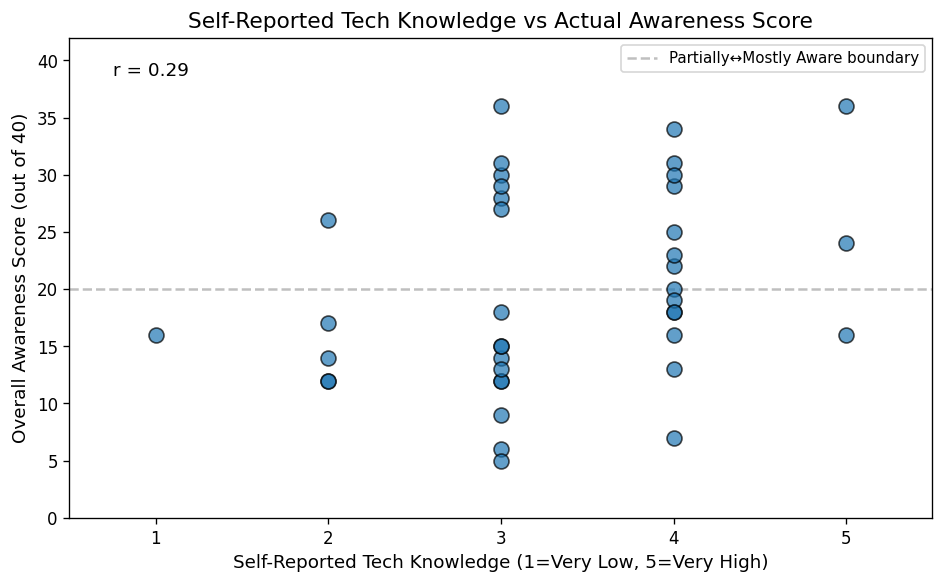



WiFi Familiarity vs Actual Scores



WiFi Familiarity = 1 (Not at all) : n=2
Overall mean: 14.0/40
        Evil Twin: 3.5/8
 Passive Sniffing: 3.5/8
             MITM: 2.5/8
    SSL Stripping: 1.0/8
     DNS Spoofing: 3.5/8

WiFi Familiarity = 2 (Not so familiar) : n=9
Overall mean: 13.4/40
        Evil Twin: 2.7/8
 Passive Sniffing: 3.1/8
             MITM: 2.8/8
    SSL Stripping: 0.7/8
     DNS Spoofing: 4.2/8

WiFi Familiarity = 3 (Somewhat) : n=21
Overall mean: 21.8/40
        Evil Twin: 4.3/8
 Passive Sniffing: 4.8/8
             MITM: 4.0/8
    SSL Stripping: 3.3/8
     DNS Spoofing: 5.4/8

WiFi Familiarity = 4 (Very familiar) : n=4
Overall mean: 24.8/40
        Evil Twin: 5.0/8
 Passive Sniffing: 4.0/8
             MITM: 3.8/8
    SSL Stripping: 4.2/8
     DNS Spoofing: 7.8/8

WiFi Familiarity = 5 (Extremely) : n=3
Overall mean: 24.0/40
        Evil Twin: 5.3/8
 Passive Sniffing: 4.3/8
             MITM: 4.7/8
    SSL Stripping: 3.7/8
     DNS Spoofing: 6.0/8


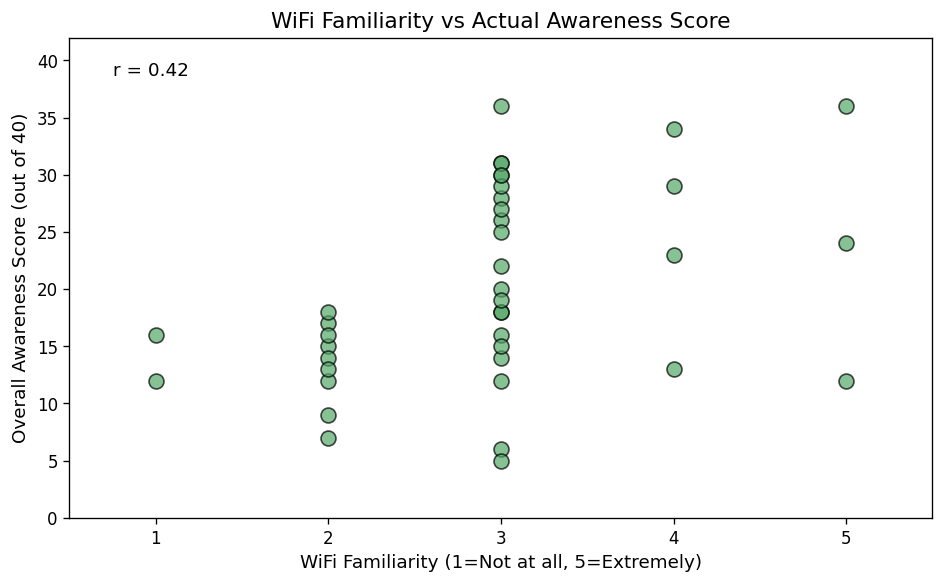



Optimism Bias vs Actual Score


Evaluating if people who feel unconcerned actually score lower

Concern = 1 (Not at all) : n=5
Overall mean: 14.0/40  |  Tiers: Partially Aware, Partially Aware, Partially Aware, Partially Aware, Partially Aware
Concern = 2 (Not so concerned) : n=12
Overall mean: 18.3/40  |  Tiers: Unaware, Mostly Aware, Partially Aware, Partially Aware, Unaware, Mostly Aware, Partially Aware, Mostly Aware, Unaware, Mostly Aware, Partially Aware, Partially Aware
Concern = 3 (Somewhat) : n=17
Overall mean: 20.4/40  |  Tiers: Partially Aware, Partially Aware, Mostly Aware, Fully Aware, Mostly Aware, Mostly Aware, Unaware, Mostly Aware, Partially Aware, Fully Aware, Partially Aware, Mostly Aware, Mostly Aware, Partially Aware, Mostly Aware, Partially Aware, Partially Aware
Concern = 4 (Very) : n=3
Overall mean: 29.7/40  |  Tiers: Fully Aware, Partially Aware, Fully Aware
Concern = 5 (Extremely) : n=2
Overall mean: 26.0/40  |  Tiers: Fully Aware, Partially Aware


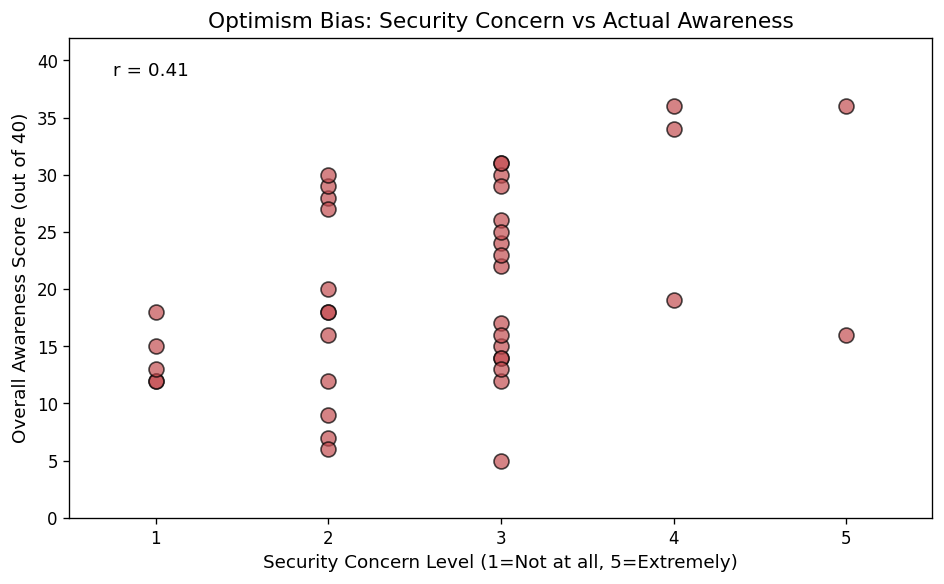



WiFi Security Attitude vs Actual Score



'Don't think about it' : n=4
Overall mean: 15.2/40  |  Tiers: Partially Aware, Partially Aware, Partially Aware, Partially Aware

'Assume mostly safe' : n=13
Overall mean: 17.5/40  |  Tiers: Unaware, Partially Aware, Unaware, Fully Aware, Mostly Aware, Partially Aware, Mostly Aware, Unaware, Mostly Aware, Partially Aware, Mostly Aware, Partially Aware, Partially Aware

'Somewhat cautious' : n=17
Overall mean: 21.2/40  |  Tiers: Mostly Aware, Partially Aware, Partially Aware, Partially Aware, Mostly Aware, Partially Aware, Fully Aware, Mostly Aware, Mostly Aware, Unaware, Mostly Aware, Partially Aware, Fully Aware, Partially Aware, Mostly Aware, Partially Aware, Partially Aware

'Actively take precautions' : n=2
Overall mean: 32.5/40  |  Tiers: Fully Aware, Mostly Aware

'Avoid public WiFi' : n=3
Overall mean: 21.7/40  |  Tiers: Partially Aware, Partially Aware, Fully Aware


Field of Work/Study vs Scores



Other : n=4
Overall mean: 17.8/40  

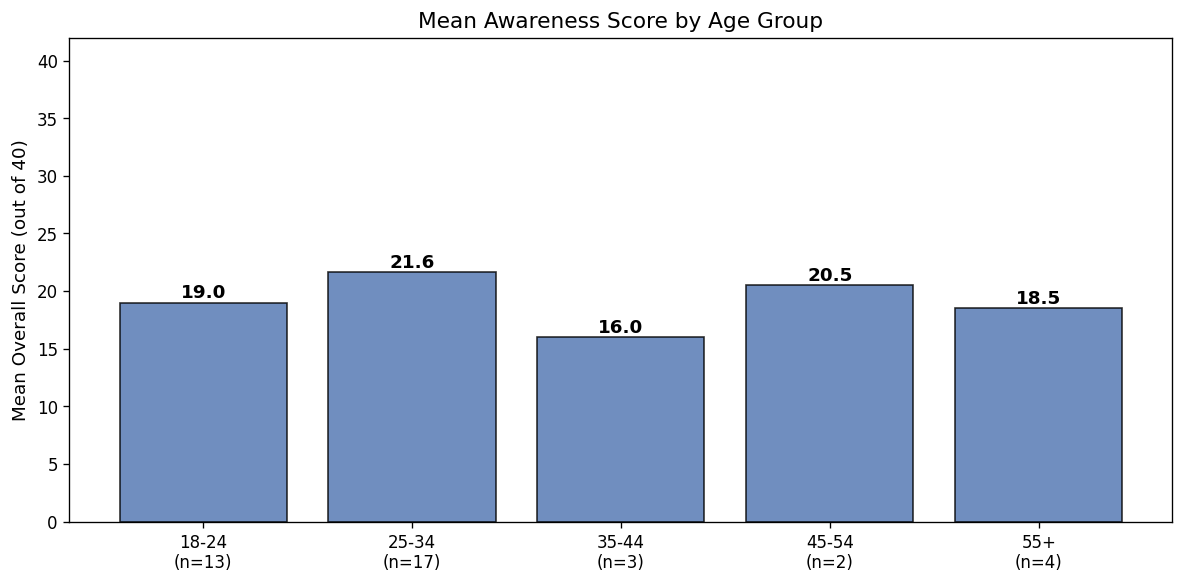

In [21]:
######### Evaluating self-reported tech knowledge vs actual scores
print("\n\nSelf-Reported Tech Knowledge vs Actual Scores\n\n")
for level in sorted(df['Tech_Knowledge'].dropna().unique()):
    subset = df[df['Tech_Knowledge'] == level]
    labels = {1:'Very Low', 2:'Low', 3:'Moderate', 4:'High', 5:'Very High'}
    print(f"\nTech Knowledge = {level} ({labels.get(level, '?')}) : n={len(subset)}")
    print(f"Overall mean: {subset['Overall_Score'].mean():.1f}/40  |  Tier(s): {', '.join(subset['Overall_Tier'].values)}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df['Tech_Knowledge'], df['Overall_Score'], s=80, alpha=0.7, edgecolors='black', zorder=3)
ax.set_xlabel('Self-Reported Tech Knowledge (1=Very Low, 5=Very High)')
ax.set_ylabel('Overall Awareness Score (out of 40)')
ax.set_title('Self-Reported Tech Knowledge vs Actual Awareness Score')
ax.set_xlim(0.5, 5.5)
ax.set_ylim(0, 42)
ax.axhline(y=20, color='gray', linestyle='--', alpha=0.5, label='Partially↔Mostly Aware boundary')
ax.legend()
corr = df[['Tech_Knowledge', 'Overall_Score']].corr().iloc[0, 1]
ax.text(0.05, 0.95, f'r = {corr:.2f}', transform=ax.transAxes, fontsize=11, verticalalignment='top')
plt.tight_layout()
plt.show()


######### Familiarity with Wifi vs. Actual Score
print("\n\nWiFi Familiarity vs Actual Scores\n\n")
for level in sorted(df['WiFi_Familiarity'].dropna().unique()):
    subset = df[df['WiFi_Familiarity'] == level]
    labels = {1:'Not at all', 2:'Not so familiar', 3:'Somewhat', 4:'Very familiar', 5:'Extremely'}
    print(f"\nWiFi Familiarity = {level} ({labels.get(level, '?')}) : n={len(subset)}")
    print(f"Overall mean: {subset['Overall_Score'].mean():.1f}/40")
    for s, name in scenario_names.items():
        print(f"{name:>17}: {subset[f'{s}_Total'].mean():.1f}/8")

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df['WiFi_Familiarity'], df['Overall_Score'], s=80, alpha=0.7, edgecolors='black', color='#55A868', zorder=3)
ax.set_xlabel('WiFi Familiarity (1=Not at all, 5=Extremely)')
ax.set_ylabel('Overall Awareness Score (out of 40)')
ax.set_title('WiFi Familiarity vs Actual Awareness Score')
ax.set_xlim(0.5, 5.5)
ax.set_ylim(0, 42)
corr = df[['WiFi_Familiarity', 'Overall_Score']].corr().iloc[0, 1]
ax.text(0.05, 0.95, f'r = {corr:.2f}', transform=ax.transAxes, fontsize=11, verticalalignment='top')
plt.tight_layout()
plt.show()

###### Optimism Bias security concern vs. Actual Score
print("\n\nOptimism Bias vs Actual Score\n\n")
print("Evaluating if people who feel unconcerned actually score lower\n")
concern_labels = {1:'Not at all', 2:'Not so concerned', 3:'Somewhat', 4:'Very', 5:'Extremely'}
for level in sorted(df['Security_Concern'].dropna().unique()):
    subset = df[df['Security_Concern'] == level]
    print(f"Concern = {level} ({concern_labels.get(level, '?')}) : n={len(subset)}")
    print(f"Overall mean: {subset['Overall_Score'].mean():.1f}/40  |  Tiers: {', '.join(subset['Overall_Tier'].values)}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df['Security_Concern'], df['Overall_Score'], s=80, alpha=0.7, edgecolors='black', color='#C44E52', zorder=3)
ax.set_xlabel('Security Concern Level (1=Not at all, 5=Extremely)')
ax.set_ylabel('Overall Awareness Score (out of 40)')
ax.set_title('Optimism Bias: Security Concern vs Actual Awareness')
ax.set_xlim(0.5, 5.5)
ax.set_ylim(0, 42)
corr = df[['Security_Concern', 'Overall_Score']].corr().iloc[0, 1]
ax.text(0.05, 0.95, f'r = {corr:.2f}', transform=ax.transAxes, fontsize=11, verticalalignment='top')
plt.tight_layout()
plt.show()

######## how they feel about wifi security and if they feel safe vs their actual score
print("\n\nWiFi Security Attitude vs Actual Score\n\n")
attitude_order = ["Don't think about it", 'Assume mostly safe', 'Somewhat cautious', 'Actively take precautions', 'Avoid public WiFi']
for att in attitude_order:
    subset = df[df['WiFi_Attitude'] == att]
    if len(subset) > 0:
        print(f"\n'{att}' : n={len(subset)}")
        print(f"Overall mean: {subset['Overall_Score'].mean():.1f}/40  |  Tiers: {', '.join(subset['Overall_Tier'].values)}")

########### Field of work/study vs scores
print("\n\nField of Work/Study vs Scores\n\n")
for field in df['Field'].dropna().unique():
    subset = df[df['Field'] == field]
    print(f"\n{field} : n={len(subset)}")
    print(f"Overall mean: {subset['Overall_Score'].mean():.1f}/40  |  Tiers: {', '.join(subset['Overall_Tier'].values)}")

########## Tech usage vs. scores
print("\n\nTech usage level vs. Scores\n\n")
for exp in ['Direct tech', 'Regular user', 'Occasional', 'Minimal']:
    subset = df[df['Tech_Experience'] == exp]
    if len(subset) > 0:
        print(f"\n'{exp}' : n={len(subset)}")
        print(f"Overall mean: {subset['Overall_Score'].mean():.1f}/40")

########## Self-Reported Wifi Threat Awareness vs. Actual Score
print("\n\nSelf-Reported Threat Awareness vs Actual Score\n\n")
print("Checking if people who claim to know threats actually score higher:\n")
for level in ['Yes', 'Somewhat', 'No']:
    subset = df[df['Aware_of_Threats'] == level]
    if len(subset) > 0:
        print(f"'{level}' : n={len(subset)}")
        print(f"Overall mean: {subset['Overall_Score'].mean():.1f}/40  |  Tiers: {', '.join(subset['Overall_Tier'].values)}")


######## Heard of specific attack vs. specific attack scenario score
print("\n\nHeard of Specific Attack vs Score on Corresponding Scenario\n\n")
attack_scenario_map = {
    'Heard_EvilTwin': ('S1_Total', 'Evil Twin'),
    'Heard_Sniffing': ('S2_Total', 'Passive Sniffing'),
    'Heard_MITM': ('S3_Total', 'MITM'),
    'Heard_SSL': ('S4_Total', 'SSL Stripping'),
    'Heard_DNS': ('S5_Total', 'DNS Spoofing'),
}
for heard_col, (score_col, name) in attack_scenario_map.items():
    heard = df[df[heard_col] == True]
    not_heard = df[df[heard_col] == False]
    h_mean = heard[score_col].mean() if len(heard) > 0 else 0
    nh_mean = not_heard[score_col].mean() if len(not_heard) > 0 else 0
    print(f"\n{name}:")
    print(f"Heard of it    (n={len(heard):2d}): mean {h_mean:.1f}/8")
    print(f"Not heard of it (n={len(not_heard):2d}): mean {nh_mean:.1f}/8")

##################### HTTPS awareness
print("\n\nHTTP/HTTPS Attention vs SSL Stripping Scenario 4 Score\n\n")
for att in ['Yes', 'Sometimes', 'No', "Don't know difference"]:
    subset = df[df['HTTP_Attention'] == att]
    if len(subset) > 0:
        print(f"\nHTTP/HTTPS attention = '{att}' : n={len(subset)}")
        print(f"  S4 (SSL Stripping) mean: {subset['S4_Total'].mean():.1f}/8")
        print(f"  Overall mean: {subset['Overall_Score'].mean():.1f}/40")

############## VPN knowledge and usage vs. scores
print("\n\nVPN Knowledge & Usage vs Scores\n\n")
for vpn in ['Yes', 'No', 'Heard of it']:
    subset = df[df['Knows_VPN'] == vpn]
    if len(subset) > 0:
        print(f"\nKnows VPN = '{vpn}' : n={len(subset)}")
        print(f"Overall mean: {subset['Overall_Score'].mean():.1f}/40")

#################### public wifi usage vs. score
print("\n\nPublic WiFi Usage Frequency vs Scores\n\n")
for freq in ['Never', 'Rarely', 'Sometimes', 'Frequently']:
    subset = df[df['WiFi_Frequency'] == freq]
    if len(subset) > 0:
        print(f"\nFrequency = '{freq}' : n={len(subset)}")
        print(f"Overall mean: {subset['Overall_Score'].mean():.1f}/40  |  Tiers: {', '.join(subset['Overall_Tier'].values)}")

################### evaluating optimism bias
print("\n\nOptimism Bias\n\n")
print("Participants who feel safe/unconcerned but scored Unaware or Partially Aware:\n")
optimism_flags = df[
    ((df['Security_Concern'] <= 2) | (df['WiFi_Attitude'].isin(["Don't think about it", 'Assume mostly safe'])))
    & (df['Overall_Tier'].isin(['Unaware', 'Partially Aware']))
]
if len(optimism_flags) > 0:
    for _, r in optimism_flags.iterrows():
        print(f"  Participant {int(r['Participant']):2d}: Concern={int(r['Security_Concern'])}/5, "
              f"Attitude='{r['WiFi_Attitude']}', Score={int(r['Overall_Score'])}/40 ({r['Overall_Tier']})")
    print(f"\n{len(optimism_flags)} of {len(df)} participants ({len(optimism_flags)/len(df)*100:.0f}%) show optimism bias")
else:
    print("No clear optimism bias cases found.")

################## Evaluating Tech Savvy Respondents who scored poorly
print("\n\nTech Savvy Reality Check\n\n")
print("Participants with high self-reported tech knowledge (4-5) who scored ≤ 20/40:\n")
tech_savvy_low = df[(df['Tech_Knowledge'] >= 4) & (df['Overall_Score'] <= 20)]
if len(tech_savvy_low) > 0:
    for _, r in tech_savvy_low.iterrows():
        print(f"Participant {int(r['Participant']):2d}: Tech Knowledge={int(r['Tech_Knowledge'])}/5, "
              f"Score={int(r['Overall_Score'])}/40 ({r['Overall_Tier']})")
    total_high_tk = (df['Tech_Knowledge'] >= 4).sum()
    print(f"\n   {len(tech_savvy_low)} of {total_high_tk} 'tech-savvy' participants ({len(tech_savvy_low)/total_high_tk*100:.0f}%) "
          f"scored at or below Partially Aware")
else:
    print("All high tech-knowledge participants scored above Partially Aware.")

from scipy import stats

########## age group vs awareness scores

print("\n\nAge Group vs Awareness Scores\n\n")

age_order = ['18-24', '25-34', '35-44', '45-54', '55+']
for age in age_order:
    subset = df[df['Age'] == age]
    if len(subset) > 0:
        print(f"\n  Age {age}  n={len(subset)}")
        print(f"    Overall mean: {subset['Overall_Score'].mean():.1f}/40  |  Tiers: {', '.join(subset['Overall_Tier'].values)}")
        for s, name in scenario_names.items():
            print(f"      {name:>17}: {subset[f'{s}_Total'].mean():.1f}/8")

fig, ax = plt.subplots(figsize=(10, 5))
age_means = []
age_labels = []
age_counts = []
for age in age_order:
    subset = df[df['Age'] == age]
    if len(subset) > 0:
        age_means.append(subset['Overall_Score'].mean())
        age_labels.append(f"{age}\n(n={len(subset)})")
        age_counts.append(len(subset))
bars = ax.bar(age_labels, age_means, color='#4C72B0', edgecolor='black', alpha=0.8)
for bar, val in zip(bars, age_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4, f'{val:.1f}', ha='center', fontweight='bold')
ax.set_ylabel('Mean Overall Score (out of 40)')
ax.set_title('Mean Awareness Score by Age Group')
ax.set_ylim(0, 42)
plt.tight_layout()
plt.show()




Scenario Score Consistency Per Participant


  R11: S1=3 S2=8 S3=6 S4=0 S5=3  |  std=3.08  range=8
  R27: S1=1 S2=0 S3=3 S4=2 S5=7  |  std=2.70  range=7
  R35: S1=6 S2=5 S3=3 S4=0 S5=1  |  std=2.55  range=6
  R 7: S1=2 S2=3 S3=3 S4=2 S5=8  |  std=2.51  range=6
  R34: S1=4 S2=3 S3=6 S4=2 S5=8  |  std=2.41  range=6
  R25: S1=7 S2=7 S3=2 S4=5 S5=8  |  std=2.39  range=6
  R39: S1=2 S2=4 S3=4 S4=0 S5=6  |  std=2.28  range=6
  R21: S1=4 S2=6 S3=3 S4=0 S5=4  |  std=2.19  range=6
  R23: S1=6 S2=2 S3=2 S4=0 S5=2  |  std=2.19  range=6
  R32: S1=3 S2=3 S3=2 S4=0 S5=6  |  std=2.17  range=6
  R31: S1=5 S2=6 S3=2 S4=1 S5=2  |  std=2.17  range=5
  R17: S1=7 S2=6 S3=4 S4=2 S5=7  |  std=2.17  range=5
  R12: S1=0 S2=0 S3=0 S4=1 S5=5  |  std=2.17  range=5
  R40: S1=8 S2=8 S3=3 S4=7 S5=8  |  std=2.17  range=5
  R36: S1=5 S2=4 S3=2 S4=1 S5=6  |  std=2.07  range=5
  R38: S1=2 S2=1 S3=6 S4=1 S5=3  |  std=2.07  range=5
  R18: S1=4 S2=3 S3=2 S4=2 S5=7  |  std=2.07  range=5
  R14: S1=7 S2=5 S3=3 S4=6 S5=8  | 

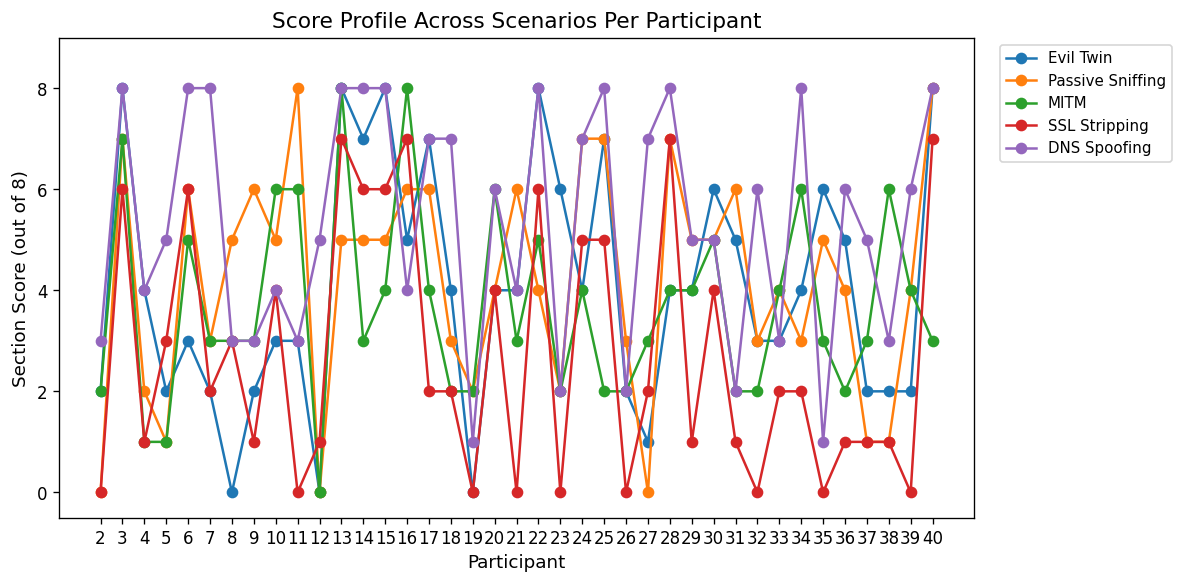



Risky Behavior  Online Banking on Public WiFi



  Participants who bank on public WiFi: 4 of 39 (10%)
    Mean overall score: 13.8/40
    Tiers: Unaware, Partially Aware, Partially Aware, Mostly Aware

    ⚠ 3 of 4 who bank on public WiFi scored Unaware or Partially Aware:
      R 2: Score=7/40 (Unaware)
      R23: Score=12/40 (Partially Aware)
      R27: Score=13/40 (Partially Aware)

  Participants who do NOT bank on public WiFi: 35
    Mean overall score: 20.7/40

  Activity frequency on public WiFi:
           Browsing: 32 participants (82%)
       Social Media: 24 participants (62%)
              Email: 25 participants (64%)
            Banking:  4 participants (10%)
          Streaming: 10 participants (26%)
        Work/School: 20 participants (51%)
           Shopping:  6 participants (15%)


Password-Protected WiFi False Sense of Security


 'Don't think about it'  n=4
    SSL Stripping / password WiFi mean: 1.5/8
    picked 'secure through hotel password' on S4 QD: 1/4

 '

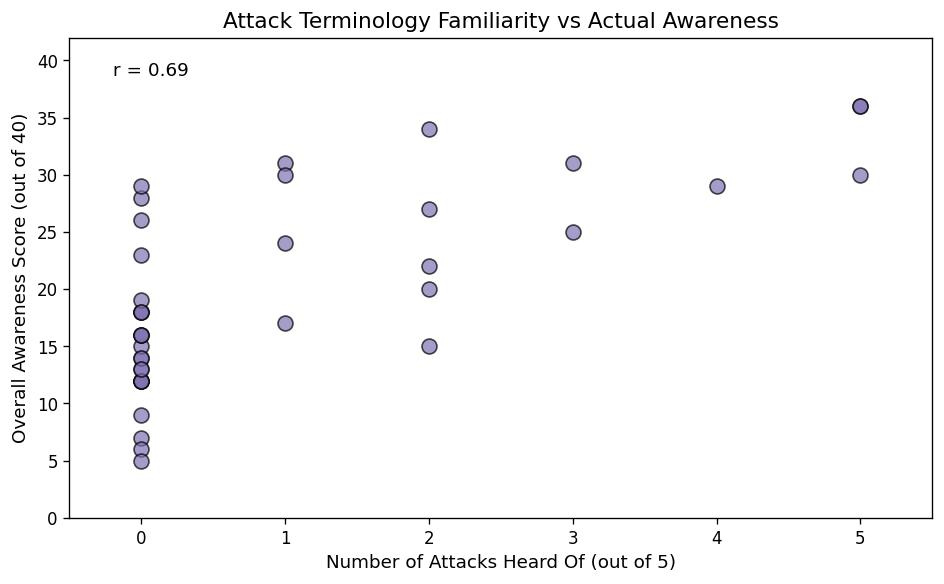


  Attack recognition rates:
            Evil Twin:  4/39 (10%)
      Packet Sniffing:  7/39 (18%)
                 MITM: 12/39 (31%)
         DNS Spoofing: 12/39 (31%)
        SSL Stripping:  4/39 (10%)


Device Type vs Scores & Risky Behavior



  Uses Phone on public WiFi  n=38
    Overall mean: 20.1/40
    Does banking: 4/38 (11%)
    Does work/school: 19/38 (50%)

  Uses Laptop on public WiFi  n=19
    Overall mean: 21.8/40
    Does banking: 3/19 (16%)
    Does work/school: 17/19 (89%)

  Uses Tablet on public WiFi  n=6
    Overall mean: 21.2/40
    Does banking: 1/6 (17%)
    Does work/school: 5/6 (83%)

  Laptop users mean: 21.8/40 (n=19)
  Phone-only users mean: 18.2/40 (n=20)
High-Risk Participants (Composite Flag)
Flagging participants who: use public WiFi sometimes/frequently,
do sensitive activities (banking/email/shopping), AND scored low.

 9 HIGH-RISK participants identified:

  R 2: Score=7/40 (Unaware), Uses WiFi=Frequently
       Activities: Browsing, Social Media, Em

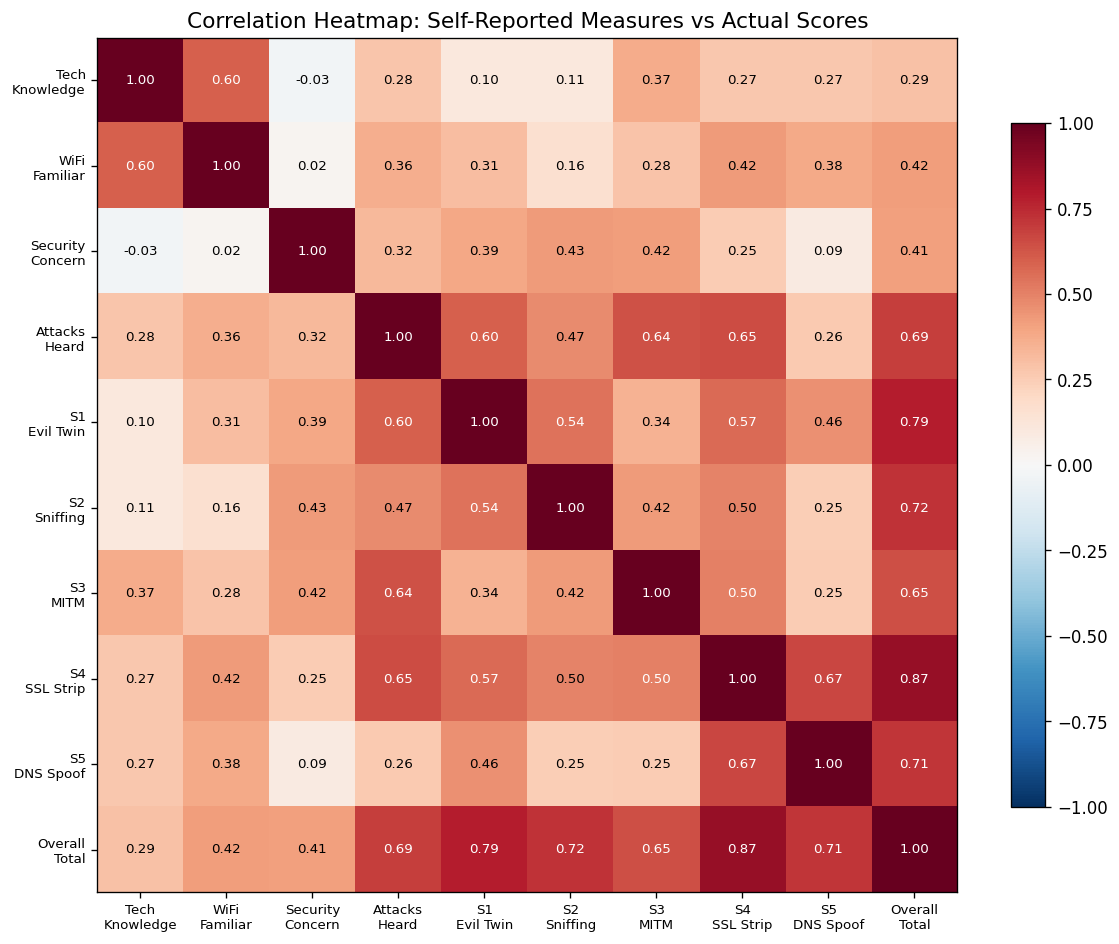


Key correlations with Overall Score:
          Tech_Knowledge: r = +0.29 (weak)
        WiFi_Familiarity: r = +0.42 (moderate)
        Security_Concern: r = +0.41 (moderate)
     Attacks_Heard_Count: r = +0.69 (strong)
Full combined dataset saved to survey_combined_full.csv


In [22]:
########## scenario score consistency per participant

print("\n\nScenario Score Consistency Per Participant\n\n")

section_total_cols = ['S1_Total', 'S2_Total', 'S3_Total', 'S4_Total', 'S5_Total']
df['Section_Std'] = df[section_total_cols].std(axis=1)
df['Section_Range'] = df[section_total_cols].max(axis=1) - df[section_total_cols].min(axis=1)

for _, r in df.sort_values('Section_Std', ascending=False).iterrows():
    scores = [int(r[c]) for c in section_total_cols]
    print(f"  R{int(r['Participant']):2d}: S1={scores[0]} S2={scores[1]} S3={scores[2]} "
          f"S4={scores[3]} S5={scores[4]}  |  std={r['Section_Std']:.2f}  range={int(r['Section_Range'])}")

avg_std = df['Section_Std'].mean()
print(f"\n  Average cross-scenario std: {avg_std:.2f}")
print(f" {'High' if avg_std > 2 else 'Moderate' if avg_std > 1.5 else 'Low'} variability  "
      f"awareness tends to be {'patchy/inconsistent' if avg_std > 1.5 else 'relatively consistent'} across attack types")

fig, ax = plt.subplots(figsize=(10, 5))
participants = df['Participant'].values
for i, s in enumerate(section_total_cols):
    ax.plot(participants, df[s].values, marker='o', label=scenario_names[s.replace('_Total', '')])
ax.set_xlabel('Participant')
ax.set_ylabel('Section Score (out of 8)')
ax.set_title('Score Profile Across Scenarios Per Participant')
ax.set_xticks(participants)
ax.set_ylim(-0.5, 9)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

########## risky behavior: banking on public wifi vs scores

print("\n\nRisky Behavior  Online Banking on Public WiFi\n\n")

# Extract who does banking on public WiFi (col 57)
df['Does_Banking'] = [pd.notna(data.iloc[i + 2, 57]) for i in range(n)]
# Extract all activities for context
activity_cols = {54:'Browsing', 55:'Social Media', 56:'Email', 57:'Banking',
                 58:'Streaming', 59:'Work/School', 60:'Shopping'}
for act_col, act_name in activity_cols.items():
    df[f'Activity_{act_name}'] = [pd.notna(data.iloc[i + 2, act_col]) for i in range(n)]

bankers = df[df['Does_Banking'] == True]
non_bankers = df[df['Does_Banking'] == False]

print(f"\n  Participants who bank on public WiFi: {len(bankers)} of {len(df)} ({len(bankers)/len(df)*100:.0f}%)")
if len(bankers) > 0:
    print(f"    Mean overall score: {bankers['Overall_Score'].mean():.1f}/40")
    print(f"    Tiers: {', '.join(bankers['Overall_Tier'].values)}")
    low_scoring_bankers = bankers[bankers['Overall_Tier'].isin(['Unaware', 'Partially Aware'])]
    if len(low_scoring_bankers) > 0:
        print(f"\n    ⚠ {len(low_scoring_bankers)} of {len(bankers)} who bank on public WiFi "
              f"scored Unaware or Partially Aware:")
        for _, r in low_scoring_bankers.iterrows():
            print(f"      R{int(r['Participant']):2d}: Score={int(r['Overall_Score'])}/40 ({r['Overall_Tier']})")

print(f"\n  Participants who do NOT bank on public WiFi: {len(non_bankers)}")
if len(non_bankers) > 0:
    print(f"    Mean overall score: {non_bankers['Overall_Score'].mean():.1f}/40")

# Activity summary
print(f"\n  Activity frequency on public WiFi:")
for act_name in activity_cols.values():
    count = df[f'Activity_{act_name}'].sum()
    print(f"    {act_name:>15}: {count:2d} participants ({count/len(df)*100:.0f}%)")

########## password-protected wifi false security

print("\n\nPassword-Protected WiFi False Sense of Security\n\n")

# S4_QA checking URL
# S4_QD http checkout behaviour "secure through hotel's password" shows false security
df['S4_QD_FalseSecurity'] = [pd.notna(data.iloc[i + 2, 177]) for i in range(n)]

# S2_QA "depends if on open network not password protected" gets 2 points
# shows if people think this is safe
df['Password_Means_Safe'] = [pd.notna(data.iloc[i + 2, 125]) for i in range(n)]

# WiFi attitude groups on S4
for att in ["Don't think about it", 'Assume mostly safe', 'Somewhat cautious',
            'Actively take precautions', 'Avoid public WiFi']:
    subset = df[df['WiFi_Attitude'] == att]
    if len(subset) > 0:
        print(f" '{att}'  n={len(subset)}")
        print(f"    SSL Stripping / password WiFi mean: {subset['S4_Total'].mean():.1f}/8")
        false_sec = subset['S4_QD_FalseSecurity'].sum()
        print(f"    picked 'secure through hotel password' on S4 QD: {false_sec}/{len(subset)}")
        print()

# # people thought password is safe in S2-QA and scored low on for S4
password_believers = df[df['Password_Means_Safe'] == True]
print(f"  Participants who said 'depends if password protected' in S2-QA: {len(password_believers)}")
if len(password_believers) > 0:
    print(f"    Their S4 mean: {password_believers['S4_Total'].mean():.1f}/8")
    print(f"    Their overall mean: {password_believers['Overall_Score'].mean():.1f}/40")

########## bad experience as a learning catalyst

print("\n\nBad Experience vs Awareness Scores\n\n")

for exp in ['Yes', 'No']:
    subset = df[df['Bad_Experience'] == exp]
    if len(subset) > 0:
        print(f"\n  Had/heard bad experience = '{exp}'  n={len(subset)}")
        print(f"    Overall mean: {subset['Overall_Score'].mean():.1f}/40")
        print(f"    Tiers: {', '.join(subset['Overall_Tier'].values)}")
        for s, name in scenario_names.items():
            print(f"      {name:>17}: {subset[f'{s}_Total'].mean():.1f}/8")

yes_group = df[df['Bad_Experience'] == 'Yes']['Overall_Score']
no_group = df[df['Bad_Experience'] == 'No']['Overall_Score']
if len(yes_group) > 1 and len(no_group) > 1:
    diff = yes_group.mean() - no_group.mean()
    print(f"\n  Difference: {'+'if diff>0 else ''}{diff:.1f} points for those with bad experience")

########## vpn usage vs actual understanding

print("\n\nVPN Usage vs Actual Understanding\n\n")
print("(Do VPN users understand WHY it helps? Check S3-QC where VPN is correct)\n")

# S3_QC vpn selection
df['S3_QC_Selected_VPN'] = [pd.notna(data.iloc[i + 2, 151]) for i in range(n)]

vpn_usage_order = ['Never', 'Rarely', 'Sometimes', 'Usually', 'Always']
for usage in vpn_usage_order:
    subset = df[df['VPN_Usage'] == usage]
    if len(subset) > 0:
        vpn_in_s3 = subset['S3_QC_Selected_VPN'].sum()
        print(f"  VPN Usage = '{usage}'  n={len(subset)}")
        print(f"    Overall mean: {subset['Overall_Score'].mean():.1f}/40")
        print(f"    S3 (MITM) mean: {subset['S3_Total'].mean():.1f}/8")
        print(f"    Selected VPN as protective in S3-QC: {vpn_in_s3}/{len(subset)}")
        print()

# people who know what a vpn is but never use it
knows_never = df[(df['Knows_VPN'] == 'Yes') & (df['VPN_Usage'] == 'Never')]
if len(knows_never) > 0:
    print(f"  Knows what a VPN is but NEVER uses it: {len(knows_never)} participants")
    print(f"    Overall mean: {knows_never['Overall_Score'].mean():.1f}/40")
    print(f"    Tiers: {', '.join(knows_never['Overall_Tier'].values)}")

########## attacks heard of vs overall score

print("\n\nNumber of Attacks Heard of vs Overall Score\n\n")

for count in sorted(df['Attacks_Heard_Count'].unique()):
    subset = df[df['Attacks_Heard_Count'] == count]
    print(f"\n  Heard of {count} attack(s)  n={len(subset)}")
    print(f"    Overall mean: {subset['Overall_Score'].mean():.1f}/40")

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df['Attacks_Heard_Count'], df['Overall_Score'], s=80, alpha=0.7,
           edgecolors='black', color='#8172B2', zorder=3)
ax.set_xlabel('Number of Attacks Heard Of (out of 5)')
ax.set_ylabel('Overall Awareness Score (out of 40)')
ax.set_title('Attack Terminology Familiarity vs Actual Awareness')
ax.set_xlim(-0.5, 5.5)
ax.set_ylim(0, 42)
corr = df[['Attacks_Heard_Count', 'Overall_Score']].corr().iloc[0, 1]
ax.text(0.05, 0.95, f'r = {corr:.2f}', transform=ax.transAxes, fontsize=11, verticalalignment='top')
plt.tight_layout()
plt.show()

# Which attacks are most/least recognized
print(f"\n  Attack recognition rates:")
for col, name in [('Heard_EvilTwin','Evil Twin'), ('Heard_Sniffing','Packet Sniffing'),
                   ('Heard_MITM','MITM'), ('Heard_DNS','DNS Spoofing'), ('Heard_SSL','SSL Stripping')]:
    count = df[col].sum()
    print(f"    {name:>17}: {count:2d}/{len(df)} ({count/len(df)*100:.0f}%)")

########## device type and risky behavior

print("\n\nDevice Type vs Scores & Risky Behavior\n\n")

device_cols = {50: 'Phone', 51: 'Laptop', 52: 'Tablet'}
for dev_col, dev_name in device_cols.items():
    df[f'Device_{dev_name}'] = [pd.notna(data.iloc[i + 2, dev_col]) for i in range(n)]

for dev_name in ['Phone', 'Laptop', 'Tablet']:
    subset = df[df[f'Device_{dev_name}'] == True]
    if len(subset) > 0:
        banking_count = subset['Does_Banking'].sum()
        work_count = subset['Activity_Work/School'].sum()
        print(f"\n  Uses {dev_name} on public WiFi  n={len(subset)}")
        print(f"    Overall mean: {subset['Overall_Score'].mean():.1f}/40")
        print(f"    Does banking: {banking_count}/{len(subset)} ({banking_count/len(subset)*100:.0f}%)")
        print(f"    Does work/school: {work_count}/{len(subset)} ({work_count/len(subset)*100:.0f}%)")

# Laptop-only sensitive tasks
laptop_users = df[df['Device_Laptop'] == True]
phone_only = df[(df['Device_Phone'] == True) & (df['Device_Laptop'] == False)]
if len(laptop_users) > 0 and len(phone_only) > 0:
    print(f"\n  Laptop users mean: {laptop_users['Overall_Score'].mean():.1f}/40 (n={len(laptop_users)})")
    print(f"  Phone-only users mean: {phone_only['Overall_Score'].mean():.1f}/40 (n={len(phone_only)})")

########## composite risk profile

print("High-Risk Participants (Composite Flag)")
print("Flagging participants who: use public WiFi sometimes/frequently,")
print("do sensitive activities (banking/email/shopping), AND scored low.\n")

df['Frequent_User'] = df['WiFi_Frequency'].isin(['Sometimes', 'Frequently'])
df['Sensitive_Activity'] = df['Does_Banking'] | df['Activity_Email'] | df['Activity_Shopping']
df['Low_Score'] = df['Overall_Tier'].isin(['Unaware', 'Partially Aware'])

high_risk = df[df['Frequent_User'] & df['Sensitive_Activity'] & df['Low_Score']]

if len(high_risk) > 0:
    print(f" {len(high_risk)} HIGH-RISK participants identified:\n")
    for _, r in high_risk.iterrows():
        activities = []
        for act_name in activity_cols.values():
            if r.get(f'Activity_{act_name}', False):
                activities.append(act_name)
        print(f"  R{int(r['Participant']):2d}: Score={int(r['Overall_Score'])}/40 ({r['Overall_Tier']}), "
              f"Uses WiFi={r['WiFi_Frequency']}")
        print(f"       Activities: {', '.join(activities)}")
        print(f"       Tech Knowledge={int(r['Tech_Knowledge'])}/5, Concern={int(r['Security_Concern'])}/5")
        print()
    print(f" {len(high_risk)} of {len(df)} participants ({len(high_risk)/len(df)*100:.0f}%) are frequent "
          f"public WiFi users doing sensitive tasks with low awareness")
else:
    print("  No high-risk composite participants found.")

########## correlation heatmap

print("\n\nCorrelation Matrix  Key Variables\n\n")

corr_cols = ['Tech_Knowledge', 'WiFi_Familiarity', 'Security_Concern',
             'Attacks_Heard_Count', 'S1_Total', 'S2_Total', 'S3_Total',
             'S4_Total', 'S5_Total', 'Overall_Score']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')

labels = ['Tech\nKnowledge', 'WiFi\nFamiliar', 'Security\nConcern',
          'Attacks\nHeard', 'S1\nEvil Twin', 'S2\nSniffing', 'S3\nMITM',
          'S4\nSSL Strip', 'S5\nDNS Spoof', 'Overall\nTotal']
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=8)
ax.set_yticklabels(labels, fontsize=8)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        val = corr_matrix.iloc[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8, color=color)

plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Correlation Heatmap: Self-Reported Measures vs Actual Scores')
plt.tight_layout()
plt.show()

print("\nKey correlations with Overall Score:")
for col in ['Tech_Knowledge', 'WiFi_Familiarity', 'Security_Concern', 'Attacks_Heard_Count']:
    r = corr_matrix.loc[col, 'Overall_Score']
    strength = 'strong' if abs(r) > 0.5 else 'moderate' if abs(r) > 0.3 else 'weak'
    print(f"  {col:>22}: r = {r:+.2f} ({strength})")


# save combined data
df.to_csv('survey_combined_full.csv', index=False)
print(f"Full combined dataset saved to survey_combined_full.csv")


In [23]:
# statistical significance tests
# non-parametric tests for ordinal data and small sample

from scipy import stats

print("\n\n************ Statistical Tests **************\n\n")

# friedman test: do awareness scores differ significantly across scenarios?
# this is a repeated-measures test since the same participants scored all 5
print("\nFriedman test: do awareness scores differ across attack scenarios?")
section_total_cols = ['S1_Total', 'S2_Total', 'S3_Total', 'S4_Total', 'S5_Total']
friedman_data = [df[c].values for c in section_total_cols]
chi2, p_fried = stats.friedmanchisquare(*friedman_data)
sig = '***' if p_fried < 0.001 else '**' if p_fried < 0.01 else '*' if p_fried < 0.05 else 'n.s.'
print(f"  Chi-squared = {chi2:.2f}, p = {p_fried:.4f} {sig}")
print(f"  Interpretation: awareness {'significantly' if p_fried < 0.05 else 'does not significantly'} "
      f"differ across the five attack scenarios")

# post-hoc pairwise wilcoxon signed-rank tests between scenarios
# only run if friedman is significant
if p_fried < 0.05:
    print(f"\n  Post-hoc pairwise Wilcoxon signed-rank tests:")
    scenario_pairs = []
    snames = list(scenario_names.items())
    for i in range(len(snames)):
        for j in range(i+1, len(snames)):
            s1_key, s1_name = snames[i]
            s2_key, s2_name = snames[j]
            stat, p = stats.wilcoxon(df[f'{s1_key}_Total'], df[f'{s2_key}_Total'])
            scenario_pairs.append((s1_name, s2_name, stat, p))

    # sort by p-value
    scenario_pairs.sort(key=lambda x: x[3])
    n_tests = len(scenario_pairs)
    print(f"  {'Pair':<35} {'W':>8} {'p-value':>10} {'Sig':>5} {'Bonf':>6}")
    print(f"  {'-'*65}")
    for s1n, s2n, w, p in scenario_pairs:
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
        bonf_sig = '*' if p < (0.05 / n_tests) else 'n.s.'
        print(f"  {s1n + ' vs ' + s2n:<35} {w:>8.1f} {p:>10.4f} {sig:>5} {bonf_sig:>6}")
    print(f"\n  Bonferroni-corrected threshold = 0.05/{n_tests} = {0.05/n_tests:.4f}")


# spearman rank correlations
print(f"\n\nSpearman rank correlations with Overall Score:")
spearman_vars = {
    'Tech_Knowledge': 'Self-reported tech knowledge',
    'WiFi_Familiarity': 'WiFi familiarity',
    'Security_Concern': 'Security concern level',
    'Attacks_Heard_Count': 'Number of attacks heard of',
}
for col, label in spearman_vars.items():
    rho, p = stats.spearmanr(df[col].dropna(), df.loc[df[col].notna(), 'Overall_Score'])
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
    print(f"  {label:>35}: rho = {rho:+.3f}, p = {p:.4f} {sig}")


# mann-whitney U tests with effect sizes
# rank-biserial correlation: r = 1 - (2U)/(n1*n2)
print(f"\n\nMann-Whitney U tests with effect sizes (rank-biserial r):")

def mann_whitney_effect(ga, gb, label):
    """run mann-whitney U, compute rank-biserial effect size, print results"""
    if len(ga) < 2 or len(gb) < 2:
        print(f"  {label}: insufficient data (n={len(ga)}, n={len(gb)})")
        return None
    u, p = stats.mannwhitneyu(ga, gb, alternative='two-sided')
    n1, n2 = len(ga), len(gb)
    r_rb = 1 - (2 * u) / (n1 * n2)  # rank-biserial correlation
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
    effect = 'large' if abs(r_rb) > 0.5 else 'medium' if abs(r_rb) > 0.3 else 'small'
    print(f"\n  {label}")
    print(f"    Group A: mean={ga.mean():.1f}, n={n1}")
    print(f"    Group B: mean={gb.mean():.1f}, n={n2}")
    print(f"    U = {u:.1f}, p = {p:.4f} {sig}, r = {r_rb:+.3f} ({effect} effect)")
    return {'label': label, 'n1': n1, 'n2': n2, 'U': u, 'p': p, 'r': r_rb, 'sig': sig, 'effect': effect}

mw_results = []

# heard of attack vs not heard (corresponding scenario score)
print(f"\n-- prior knowledge of attack vs corresponding scenario score --")
attack_scenario_map = {
    'Heard_EvilTwin': ('S1_Total', 'Evil Twin'),
    'Heard_Sniffing': ('S2_Total', 'Passive Sniffing'),
    'Heard_MITM': ('S3_Total', 'MITM'),
    'Heard_SSL': ('S4_Total', 'SSL Stripping'),
    'Heard_DNS': ('S5_Total', 'DNS Spoofing'),
}
for heard_col, (score_col, name) in attack_scenario_map.items():
    h = df[df[heard_col] == True][score_col]
    nh = df[df[heard_col] == False][score_col]
    res = mann_whitney_effect(h, nh, f'Heard {name} vs not')
    if res: mw_results.append(res)

# tech knowledge high vs low
print(f"\n-- self-reported tech knowledge groups --")
high_tk = df[df['Tech_Knowledge'] >= 4]['Overall_Score']
low_tk = df[df['Tech_Knowledge'] < 4]['Overall_Score']
res = mann_whitney_effect(high_tk, low_tk, 'Tech knowledge High(4-5) vs Low(1-3)')
if res: mw_results.append(res)

# security concern low vs high
print(f"\n-- security concern groups --")
low_c = df[df['Security_Concern'] <= 2]['Overall_Score']
high_c = df[df['Security_Concern'] >= 4]['Overall_Score']
res = mann_whitney_effect(low_c, high_c, 'Concern Low(1-2) vs High(4-5)')
if res: mw_results.append(res)

# VPN knowledge
print(f"\n-- VPN knowledge --")
vpn_y = df[df['Knows_VPN'] == 'Yes']['Overall_Score']
vpn_n = df[df['Knows_VPN'] != 'Yes']['Overall_Score']
res = mann_whitney_effect(vpn_y, vpn_n, 'Knows VPN vs does not')
if res: mw_results.append(res)

# bad experience
print(f"\n-- bad experience --")
yes_exp = df[df['Bad_Experience'] == 'Yes']['Overall_Score']
no_exp = df[df['Bad_Experience'] == 'No']['Overall_Score']
res = mann_whitney_effect(yes_exp, no_exp, 'Bad experience vs none')
if res: mw_results.append(res)

# kruskal-wallis for wifi usage frequency
print(f"\n\nKruskal-Wallis: WiFi usage frequency vs overall score")
freq_groups = []
freq_labels = []
for freq in ['Never', 'Rarely', 'Sometimes', 'Frequently']:
    subset = df[df['WiFi_Frequency'] == freq]['Overall_Score']
    if len(subset) > 0:
        freq_groups.append(subset.values)
        freq_labels.append(f"{freq} (n={len(subset)})")
if len(freq_groups) >= 2:
    h_stat, p_val = stats.kruskal(*freq_groups)
    sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'n.s.'
    print(f"  Groups: {', '.join(freq_labels)}")
    print(f"  H = {h_stat:.2f}, p = {p_val:.4f} {sig}")

# multiple comparisons note
n_mw = len(mw_results)
print(f"\n\nNote on multiple comparisons:")
print(f"  {n_mw} Mann-Whitney U tests were conducted.")
print(f"  Without correction, the family-wise error rate at alpha=0.05 is approximately "
      f"{1 - (1 - 0.05)**n_mw:.2f}.")
print(f"  Bonferroni-corrected threshold: 0.05/{n_mw} = {0.05/n_mw:.4f}")
print(f"  Results that survive Bonferroni correction:")
for res in mw_results:
    if res['p'] < (0.05 / n_mw):
        print(f"    {res['label']}: p = {res['p']:.4f}")
survive_count = sum(1 for r in mw_results if r['p'] < (0.05 / n_mw))
if survive_count == 0:
    print(f"    (none survive Bonferroni correction)")


# population segmentation analyses

print("\n\n*********Population Segmentation Analyses*************\n\n")


# works in tech vs does not
print(f"\n\n--- Works in Tech vs Does Not ---")
tech_field = df[df['Tech_Experience'] == 'Direct tech']
non_tech_field = df[df['Tech_Experience'] != 'Direct tech']
print(f"  Works directly in tech: n={len(tech_field)}, mean={tech_field['Overall_Score'].mean():.1f}/40")
print(f"  Does not work in tech:  n={len(non_tech_field)}, mean={non_tech_field['Overall_Score'].mean():.1f}/40")

# tiers breakdown
print(f"\n  Tier breakdown:")
print(f"  {'Tier':<20} {'Tech':>8} {'Non-tech':>10}")
for tier in ['Unaware', 'Partially Aware', 'Mostly Aware', 'Fully Aware']:
    t_ct = (tech_field['Overall_Tier'] == tier).sum()
    nt_ct = (non_tech_field['Overall_Tier'] == tier).sum()
    print(f"  {tier:<20} {t_ct:>4} ({t_ct/len(tech_field)*100:>4.0f}%) {nt_ct:>4} ({nt_ct/len(non_tech_field)*100:>4.0f}%)")

# per-scenario comparison
print(f"\n  Per-scenario means:")
print(f"  {'Scenario':<20} {'Tech':>8} {'Non-tech':>10}")
for s, name in scenario_names.items():
    t_m = tech_field[f'{s}_Total'].mean()
    nt_m = non_tech_field[f'{s}_Total'].mean()
    print(f"  {name:<20} {t_m:>8.1f} {nt_m:>10.1f}")

# statistical test
res = mann_whitney_effect(
    tech_field['Overall_Score'], non_tech_field['Overall_Score'],
    'Works in tech vs does not (overall score)')

# tech workers who still scored poorly
tech_low = tech_field[tech_field['Overall_Tier'].isin(['Unaware', 'Partially Aware'])]
print(f"\n  Tech workers who scored Unaware or Partially Aware: {len(tech_low)}/{len(tech_field)} "
      f"({len(tech_low)/len(tech_field)*100:.0f}%)")
for _, r in tech_low.iterrows():
    print(f"    P{int(r['Participant'])}: TK={int(r['Tech_Knowledge'])}/5, "
          f"Score={int(r['Overall_Score'])}/40 ({r['Overall_Tier']})")

# which scenarios do tech workers struggle with?
if len(tech_field) > 0:
    print(f"\n Tech workers' weakest scenario:")
    tech_scenario_means = {name: tech_field[f'{s}_Total'].mean() for s, name in scenario_names.items()}
    weakest = min(tech_scenario_means, key=tech_scenario_means.get)
    print(f"    {weakest}: {tech_scenario_means[weakest]:.1f}/8")

# tech-savvy self-reported 4-5 vs not 1-3
print(f"\n\n--- Self-Reported Tech-Savvyvs Not ---")
tech_savvy = df[df['Tech_Knowledge'] >= 4]
non_savvy = df[df['Tech_Knowledge'] < 4]
print(f"  Tech-savvy (4-5): n={len(tech_savvy)}, mean={tech_savvy['Overall_Score'].mean():.1f}/40")
print(f"  Not tech-savvy (1-3): n={len(non_savvy)}, mean={non_savvy['Overall_Score'].mean():.1f}/40")

print(f"\n  Tier breakdown:")
print(f"  {'Tier':<20} {'Savvy':>8} {'Not savvy':>10}")
for tier in ['Unaware', 'Partially Aware', 'Mostly Aware', 'Fully Aware']:
    s_ct = (tech_savvy['Overall_Tier'] == tier).sum()
    ns_ct = (non_savvy['Overall_Tier'] == tier).sum()
    print(f"  {tier:<20} {s_ct:>4} ({s_ct/len(tech_savvy)*100:>4.0f}%) {ns_ct:>4} ({ns_ct/len(non_savvy)*100:>4.0f}%)")

print(f"\n  Per-scenario means:")
print(f"  {'Scenario':<20} {'Savvy':>8} {'Not savvy':>10}")
for s, name in scenario_names.items():
    s_m = tech_savvy[f'{s}_Total'].mean()
    ns_m = non_savvy[f'{s}_Total'].mean()
    print(f"  {name:<20} {s_m:>8.1f} {ns_m:>10.1f}")

# tech-savvy who scored poorly (the "reality check")
savvy_low = tech_savvy[tech_savvy['Overall_Score'] <= 20]
print(f"\n  Tech-savvy participants who scored Partially Aware or below:")
print(f"    {len(savvy_low)}/{len(tech_savvy)} ({len(savvy_low)/len(tech_savvy)*100:.0f}%)")
for _, r in savvy_low.iterrows():
    print(f"    P{int(r['Participant'])}: TK={int(r['Tech_Knowledge'])}/5, Field={r['Field']}, "
          f"Score={int(r['Overall_Score'])}/40")

# where specifically do tech-savvy people fail?
print(f"\n  Scenario where tech-savvy still score poorly:")
for s, name in scenario_names.items():
    savvy_unaware = (tech_savvy[f'{s}_Tier'] == 'Unaware').sum()
    if savvy_unaware > 0:
        print(f"    {name}: {savvy_unaware}/{len(tech_savvy)} tech-savvy scored Unaware "
              f"({savvy_unaware/len(tech_savvy)*100:.0f}%)")

# self-reported threat awareness vs actual performance
print(f"\n\n--- Self-Reported Threat Awareness vs Actual ---")
for level in ['Yes', 'Somewhat', 'No']:
    subset = df[df['Aware_of_Threats'] == level]
    if len(subset) > 0:
        print(f"\n  Claims awareness = '{level}': n={len(subset)}, mean={subset['Overall_Score'].mean():.1f}/40")
        for tier in ['Unaware', 'Partially Aware', 'Mostly Aware', 'Fully Aware']:
            ct = (subset['Overall_Tier'] == tier).sum()
            if ct > 0:
                print(f"    {tier}: {ct} ({ct/len(subset)*100:.0f}%)")

# kruskal-wallis for self-reported awareness groups
aware_groups = []
aware_labels = []
for level in ['Yes', 'Somewhat', 'No']:
    subset = df[df['Aware_of_Threats'] == level]['Overall_Score']
    if len(subset) > 0:
        aware_groups.append(subset.values)
        aware_labels.append(f"{level} (n={len(subset)})")
if len(aware_groups) >= 2:
    h_stat, p_val = stats.kruskal(*aware_groups)
    sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'n.s.'
    print(f"\n  Kruskal-Wallis: H = {h_stat:.2f}, p = {p_val:.4f} {sig}")

# people who claimed "Yes" but scored poorly
yes_low = df[(df['Aware_of_Threats'] == 'Yes') & (df['Overall_Tier'].isin(['Unaware', 'Partially Aware']))]
print(f"\n  Claimed aware but scored Partially Aware or below: {len(yes_low)}/{(df['Aware_of_Threats']=='Yes').sum()}")
for _, r in yes_low.iterrows():
    print(f"    P{int(r['Participant'])}: Score={int(r['Overall_Score'])}/40 ({r['Overall_Tier']})")

# people who claimed "No" but scored well
no_high = df[(df['Aware_of_Threats'] == 'No') & (df['Overall_Tier'].isin(['Mostly Aware', 'Fully Aware']))]
print(f"\n  Claimed unaware but scored Mostly Aware or above: {len(no_high)}/{(df['Aware_of_Threats']=='No').sum()}")
for _, r in no_high.iterrows():
    print(f"    P{int(r['Participant'])}: Score={int(r['Overall_Score'])}/40 ({r['Overall_Tier']})")

# age demographics
print(f"\n\n--- Age Demographics ---")
age_order = ['18-24', '25-34', '35-44', '45-54', '55+']

print(f"\n  Overall scores by age group:")
print(f"  {'Age':<10} {'n':>4} {'Mean':>8} {'Median':>8} {'SD':>8}")
for age in age_order:
    subset = df[df['Age'] == age]
    if len(subset) > 0:
        print(f"  {age:<10} {len(subset):>4} {subset['Overall_Score'].mean():>8.1f} "
              f"{subset['Overall_Score'].median():>8.1f} {subset['Overall_Score'].std():>8.1f}")

# focus on the two largest groups for meaningful comparison
g1824 = df[df['Age'] == '18-24']['Overall_Score']
g2534 = df[df['Age'] == '25-34']['Overall_Score']
if len(g1824) >= 5 and len(g2534) >= 5:
    print(f"\n  Mann-Whitney U: 18-24 vs 25-34 (two largest groups)")
    mann_whitney_effect(g2534, g1824, '25-34 vs 18-24 overall score')

# field of work comparison
print(f"\n\n--- Field of Study/Work ---")
print(f"\n  {'Field':<25} {'n':>4} {'Mean':>8} {'Median':>8}")
for field in ['Tech/IT/SW/Eng', 'Business/Finance', 'Education', 'Arts/Media/Design',
              'Healthcare', 'Trades/Labour', 'Other']:
    subset = df[df['Field'] == field]
    if len(subset) > 0:
        print(f"  {field:<25} {len(subset):>4} {subset['Overall_Score'].mean():>8.1f} "
              f"{subset['Overall_Score'].median():>8.1f}")

# tech vs business/finance (two professional fields with enough n)
tech_f = df[df['Field'] == 'Tech/IT/SW/Eng']['Overall_Score']
biz_f = df[df['Field'] == 'Business/Finance']['Overall_Score']
if len(tech_f) >= 5 and len(biz_f) >= 5:
    print(f"\n  Mann-Whitney U: Tech/IT vs Business/Finance")
    mann_whitney_effect(tech_f, biz_f, 'Tech/IT vs Business/Finance')

# kruskal-wallis across all fields with n >= 3
field_groups = []
field_names = []
for field in df['Field'].value_counts().index:
    subset = df[df['Field'] == field]['Overall_Score']
    if len(subset) >= 3:
        field_groups.append(subset.values)
        field_names.append(f"{field} (n={len(subset)})")
if len(field_groups) >= 3:
    h_stat, p_val = stats.kruskal(*field_groups)
    sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'n.s.'
    print(f"\n  Kruskal-Wallis across fields (n>=3): H = {h_stat:.2f}, p = {p_val:.4f} {sig}")





************ Statistical Tests **************



Friedman test: do awareness scores differ across attack scenarios?
  Chi-squared = 40.60, p = 0.0000 ***
  Interpretation: awareness significantly differ across the five attack scenarios

  Post-hoc pairwise Wilcoxon signed-rank tests:
  Pair                                       W    p-value   Sig   Bonf
  -----------------------------------------------------------------
  SSL Stripping vs DNS Spoofing           23.0     0.0000   ***      *
  MITM vs DNS Spoofing                    77.0     0.0008   ***      *
  Passive Sniffing vs SSL Stripping       96.0     0.0009   ***      *
  Evil Twin vs SSL Stripping             131.5     0.0014    **      *
  Evil Twin vs DNS Spoofing               74.5     0.0031    **      *
  MITM vs SSL Stripping                  182.5     0.0168     *   n.s.
  Passive Sniffing vs DNS Spoofing       162.0     0.0199     *   n.s.
  Passive Sniffing vs MITM               166.0     0.1674  n.s.   n.s.
  Evil

In [24]:
# optimism bias analysis

print("Optimism Bias Analysis")

# low concern & casual attitude & low score
opt_strict = df[
    (df['Security_Concern'] <= 2)
    & (df['WiFi_Attitude'].isin(["Don't think about it", 'Assume mostly safe']))
    & (df['Overall_Tier'].isin(['Unaware', 'Partially Aware']))
]

print(f"\n  Strict definition (low concern AND casual attitude AND low score):")
print(f"    {len(opt_strict)}/{len(df)} participants ({len(opt_strict)/len(df)*100:.0f}%)")

print(f"\n  Strict optimism bias cases:")
for _, r in opt_strict.iterrows():
    print(f"    P{int(r['Participant'])}: Concern={int(r['Security_Concern'])}/5, "
          f"Attitude='{r['WiFi_Attitude']}', Score={int(r['Overall_Score'])}/40 ({r['Overall_Tier']})")

TIER_ORDER = ['Unaware', 'Partially Aware', 'Mostly Aware', 'Fully Aware']

# research question summary

print("\n\nResearch Qs\n\n")

print(f"\nRQ1")
print("\n-----------------------\n")
print(f"  Overall: mean={df['Overall_Score'].mean():.1f}/40, median={df['Overall_Score'].median():.0f}")
for tier in TIER_ORDER:
    ct = (df['Overall_Tier'] == tier).sum()
    print(f"    {tier}: {ct}/{len(df)} ({ct/len(df)*100:.0f}%)")
print(f"\n  Scenario ranking (Friedman Chi2={chi2:.2f}, p={p_fried:.4f}):")
ranked = sorted(scenario_names.items(), key=lambda x: df[f'{x[0]}_Total'].mean(), reverse=True)
for rank, (s, name) in enumerate(ranked, 1):
    m = df[f'{s}_Total'].mean()
    u_pct = (df[f'{s}_Tier']=='Unaware').sum()/len(df)*100
    print(f"    {rank}. {name:>17}: mean={m:.1f}/8, {u_pct:.0f}% Unaware")

print(f"\nRQ2")
print("\n-------------------\n")
rho_tk, p_tk = stats.spearmanr(df['Tech_Knowledge'].dropna(),
                                df.loc[df['Tech_Knowledge'].notna(), 'Overall_Score'])
print(f"  Spearman rho = {rho_tk:+.3f}, p = {p_tk:.4f}")
print(f"  Tech-savvy (4-5) who scored Partially Aware or below: "
      f"{len(savvy_low)}/{len(tech_savvy)} ({len(savvy_low)/len(tech_savvy)*100:.0f}%)")
print(f"  Tech field workers: mean={tech_field['Overall_Score'].mean():.1f}/40 "
      f"vs non-tech: {non_tech_field['Overall_Score'].mean():.1f}/40")
print(f"  Tech workers' weakest scenario: SSL Stripping "
      f"({tech_field['S4_Total'].mean():.1f}/8)")

print("n\RQ3")
print("\n----------------------------")
rho_sc, p_sc = stats.spearmanr(df['Security_Concern'].dropna(),
                                df.loc[df['Security_Concern'].notna(), 'Overall_Score'])
print(f"  Concern vs score: rho = {rho_sc:+.3f}, p = {p_sc:.4f}")
print(f"  Optimism bias: {len(opt_strict)}/{len(df)} ({len(opt_strict)/len(df)*100:.0f}%)")


plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'figure.titlesize': 14,
})

TIER_COLORS = {
    'Unaware': '#d62728',
    'Partially Aware': '#ff7f0e',
    'Mostly Aware': '#2ca02c',
    'Fully Aware': '#1f77b4',
}
TIER_ORDER = ['Unaware', 'Partially Aware', 'Mostly Aware', 'Fully Aware']
SCENARIO_COLORS = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']

FIG_DIR = ''
fig_counter = 0

def save_fig(fig, name):
    global fig_counter
    fig_counter += 1
    if FIG_DIR:
        fig.savefig(f"{FIG_DIR}{name}.png", bbox_inches='tight')
    plt.show()


# table 1 participant demographics

print("\n\n***********Table 1: Participant Demographics (n={})**********\n\n".format(len(df)))

print(f"\n  {'Category':<30} {'Group':<30} {'n':>4} {'%':>6}")
print(f"  {'-'*74}")

for age in ['18-24', '25-34', '35-44', '45-54', '55+']:
    ct = (df['Age'] == age).sum()
    cat = 'Age' if age == '18-24' else ''
    if ct > 0:
        print(f"  {cat:<30} {age:<30} {ct:>4} {ct/len(df)*100:>5.1f}%")

for field in ['Tech/IT/SW/Eng', 'Business/Finance', 'Trades/Labour', 'Arts/Media/Design',
              'Education', 'Healthcare', 'Other']:
    ct = (df['Field'] == field).sum()
    cat = 'Field of study/work' if field == 'Tech/IT/SW/Eng' else ''
    if ct > 0:
        print(f"  {cat:<30} {field:<30} {ct:>4} {ct/len(df)*100:>5.1f}%")

for exp in ['Direct tech', 'Regular user', 'Occasional', 'Minimal']:
    ct = (df['Tech_Experience'] == exp).sum()
    cat = 'Tech experience' if exp == 'Direct tech' else ''
    if ct > 0:
        print(f"  {cat:<30} {exp:<30} {ct:>4} {ct/len(df)*100:>5.1f}%")

tk_labels = {1:'Very Low', 2:'Low', 3:'Moderate', 4:'High', 5:'Very High'}
for level in [1,2,3,4,5]:
    ct = (df['Tech_Knowledge'] == level).sum()
    cat = 'Tech knowledge (1-5)' if level == 1 else ''
    if ct > 0:
        print(f"  {cat:<30} {str(int(level)) + ' (' + tk_labels[level] + ')':<30} {ct:>4} {ct/len(df)*100:>5.1f}%")

for freq in ['Never', 'Rarely', 'Sometimes', 'Frequently']:
    ct = (df['WiFi_Frequency'] == freq).sum()
    cat = 'WiFi usage frequency' if freq == 'Never' else ''
    if ct > 0:
        print(f"  {cat:<30} {freq:<30} {ct:>4} {ct/len(df)*100:>5.1f}%")

concern_labels = {1:'Not at all', 2:'Not so concerned', 3:'Somewhat', 4:'Very', 5:'Extremely'}
for level in [1,2,3,4,5]:
    ct = (df['Security_Concern'] == level).sum()
    cat = 'Security concern (1-5)' if level == 1 else ''
    if ct > 0:
        print(f"  {cat:<30} {str(int(level)) + ' (' + concern_labels[level] + ')':<30} {ct:>4} {ct/len(df)*100:>5.1f}%")


# Table 2 descriptive statistics

print("\n\n**********Table 2: Per-Scenario Awareness Scores and Tier Distributions*********\n\n")

header = f"{'Scenario':<20} {'Mean':>5} {'Med':>4} {'SD':>5} {'Unaware':>8} {'Partial':>8} {'Mostly':>8} {'Fully':>8}"
print(f"\n  {header}")
print(f"  {'-'*len(header)}")

for s, name in scenario_names.items():
    total_col = f'{s}_Total'
    tier_col = f'{s}_Tier'
    mean = df[total_col].mean()
    med = df[total_col].median()
    sd = df[total_col].std()
    tiers = [(df[tier_col] == t).sum() for t in TIER_ORDER]
    print(f"  {name:<20} {mean:>5.2f} {med:>4.1f} {sd:>5.2f} "
          f"{tiers[0]:>8d} {tiers[1]:>8d} {tiers[2]:>8d} {tiers[3]:>8d}")

mean_o = df['Overall_Score'].mean()
med_o = df['Overall_Score'].median()
sd_o = df['Overall_Score'].std()
tiers_o = [(df['Overall_Tier'] == t).sum() for t in TIER_ORDER]
print(f"  {'-'*len(header)}")
print(f"  {'Overall (/40)':<20} {mean_o:>5.2f} {med_o:>4.1f} {sd_o:>5.2f} "
      f"{tiers_o[0]:>8d} {tiers_o[1]:>8d} {tiers_o[2]:>8d} {tiers_o[3]:>8d}")
print(f"\n  Scenario scores out of 8. Overall out of 40.")
print(f"  Friedman test: Chi2={chi2:.2f}, p={p_fried:.4f}")



print("\n\n************Table 3 Statistical Test Results****************\n\n")

print(f"\n  3.1 Spearman Rank Correlations with Overall Score")
print(f"  {'Variable':<35} {'rho':>7} {'p':>10} {'Sig':>5}")
print("\n------------------------------------------------\n\n")
for col, label in spearman_vars.items():
    rho, p = stats.spearmanr(df[col].dropna(), df.loc[df[col].notna(), 'Overall_Score'])
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
    print(f"  {label:<35} {rho:>+7.3f} {p:>10.4f} {sig:>5}")

print(f"\n  3.2: Mann-Whitney U Tests (with rank-biserial effect size)")
print(f"  {'Comparison':<35} {'n1':>4} {'n2':>4} {'U':>8} {'p':>10} {'Sig':>5} {'r':>7} {'Effect':>8}")
print(f"  {'-'*85}")
for res in mw_results:
    print(f"  {res['label']:<35} {res['n1']:>4} {res['n2']:>4} {res['U']:>8.1f} "
          f"{res['p']:>10.4f} {res['sig']:>5} {res['r']:>+7.3f} {res['effect']:>8}")

print(f"\n  * p < 0.05, ** p < 0.01, *** p < 0.001")
print(f"  Effect size: |r| > 0.5 = large, > 0.3 = medium, <= 0.3 = small")



print("\n\n**************Additional Calculations for Discussion*******************\n\n")

# password-protected wifi false security
print(f"\n  Password-protected WiFi false security:")
df['S4_QD_FalseSecurity'] = [pd.notna(data.iloc[i + 2, 177]) for i in range(n)]
false_sec_ct = df['S4_QD_FalseSecurity'].sum()
print(f"    Chose 'secure through hotel password' on S4-QD: {false_sec_ct}/{len(df)} ({false_sec_ct/len(df)*100:.0f}%)")
if false_sec_ct > 0:
    fs_scores = df[df['S4_QD_FalseSecurity'] == True]['S4_Total']
    other_scores = df[df['S4_QD_FalseSecurity'] == False]['S4_Total']
    print(f"    Their S4 mean: {fs_scores.mean():.1f}/8 vs others: {other_scores.mean():.1f}/8")

# http/https attention vs S4
print(f"\n  HTTP/HTTPS attention vs SSL stripping score:")
for att in ['Yes', 'Sometimes', 'No', "Don't know difference"]:
    subset = df[df['HTTP_Attention'] == att]
    if len(subset) > 0:
        print(f"    '{att}': n={len(subset)}, S4={subset['S4_Total'].mean():.1f}/8, Overall={subset['Overall_Score'].mean():.1f}/40")

# banking risk
print(f"\n  Online banking on public WiFi:")
bankers = df[df['Does_Banking'] == True]
non_bankers = df[df['Does_Banking'] == False]
print(f"    Banks: {len(bankers)}/{len(df)} ({len(bankers)/len(df)*100:.0f}%), mean={bankers['Overall_Score'].mean():.1f}/40")
low_bankers = bankers[bankers['Overall_Tier'].isin(['Unaware', 'Partially Aware'])]
print(f"    Of those, scored low: {len(low_bankers)}/{len(bankers)}")

# activities
print(f"\n  Activities on public WiFi:")
activity_cols_map = {54:'Browsing', 55:'Social Media', 56:'Email', 57:'Banking',
                     58:'Streaming', 59:'Work/School', 60:'Shopping'}
for col, act in activity_cols_map.items():
    ct = df[f'Activity_{act}'].sum() if f'Activity_{act}' in df.columns else 0
    print(f"    {act}: {ct}/{len(df)} ({ct/len(df)*100:.0f}%)")

# vpn deep-dive
print(f"\n  VPN knowledge and usage:")
for vpn in ['Yes', 'No', 'Heard of it']:
    subset = df[df['Knows_VPN'] == vpn]
    if len(subset) > 0:
        print(f"    Knows VPN='{vpn}': n={len(subset)}, mean={subset['Overall_Score'].mean():.1f}/40")
knows_never = df[(df['Knows_VPN'] == 'Yes') & (df['VPN_Usage'] == 'Never')]
if len(knows_never) > 0:
    print(f"    Knows VPN but never uses it: {len(knows_never)}, mean={knows_never['Overall_Score'].mean():.1f}/40")

# bad experience
print(f"\n  Bad experience vs awareness:")
for exp in ['Yes', 'No']:
    subset = df[df['Bad_Experience'] == exp]
    if len(subset) > 0:
        print(f"    {exp}: n={len(subset)}, mean={subset['Overall_Score'].mean():.1f}/40")

# high-risk composite
print(f"\n  High-risk participants (frequent + sensitive activity + low score):")
high_risk = df[df['Frequent_User'] & df['Sensitive_Activity'] & df['Low_Score']]
print(f"    Count: {len(high_risk)}/{len(df)} ({len(high_risk)/len(df)*100:.0f}%)")

# cross-scenario consistency
df['Section_Std'] = df[section_total_cols].std(axis=1)
print(f"\n  Cross-scenario consistency:")
print(f"    Average std: {df['Section_Std'].mean():.2f}")
print(f"    Interpretation: awareness is patchy across attack types")



Optimism Bias Analysis

  Strict definition (low concern AND casual attitude AND low score):
    10/39 participants (26%)

  Strict optimism bias cases:
    P2: Concern=2/5, Attitude='Assume mostly safe', Score=7/40 (Unaware)
    P4: Concern=1/5, Attitude='Don't think about it', Score=12/40 (Partially Aware)
    P5: Concern=1/5, Attitude='Assume mostly safe', Score=12/40 (Partially Aware)
    P12: Concern=2/5, Attitude='Assume mostly safe', Score=6/40 (Unaware)
    P18: Concern=2/5, Attitude='Don't think about it', Score=18/40 (Partially Aware)
    P26: Concern=2/5, Attitude='Assume mostly safe', Score=9/40 (Unaware)
    P27: Concern=1/5, Attitude='Don't think about it', Score=13/40 (Partially Aware)
    P33: Concern=2/5, Attitude='Assume mostly safe', Score=16/40 (Partially Aware)
    P36: Concern=1/5, Attitude='Don't think about it', Score=18/40 (Partially Aware)
    P37: Concern=2/5, Attitude='Assume mostly safe', Score=12/40 (Partially Aware)


Research Qs



RQ1

-----------------

<>:51: SyntaxWarning: invalid escape sequence '\R'
<>:51: SyntaxWarning: invalid escape sequence '\R'
/tmp/ipykernel_14009/1360220822.py:51: SyntaxWarning: invalid escape sequence '\R'
  print("n\RQ3")


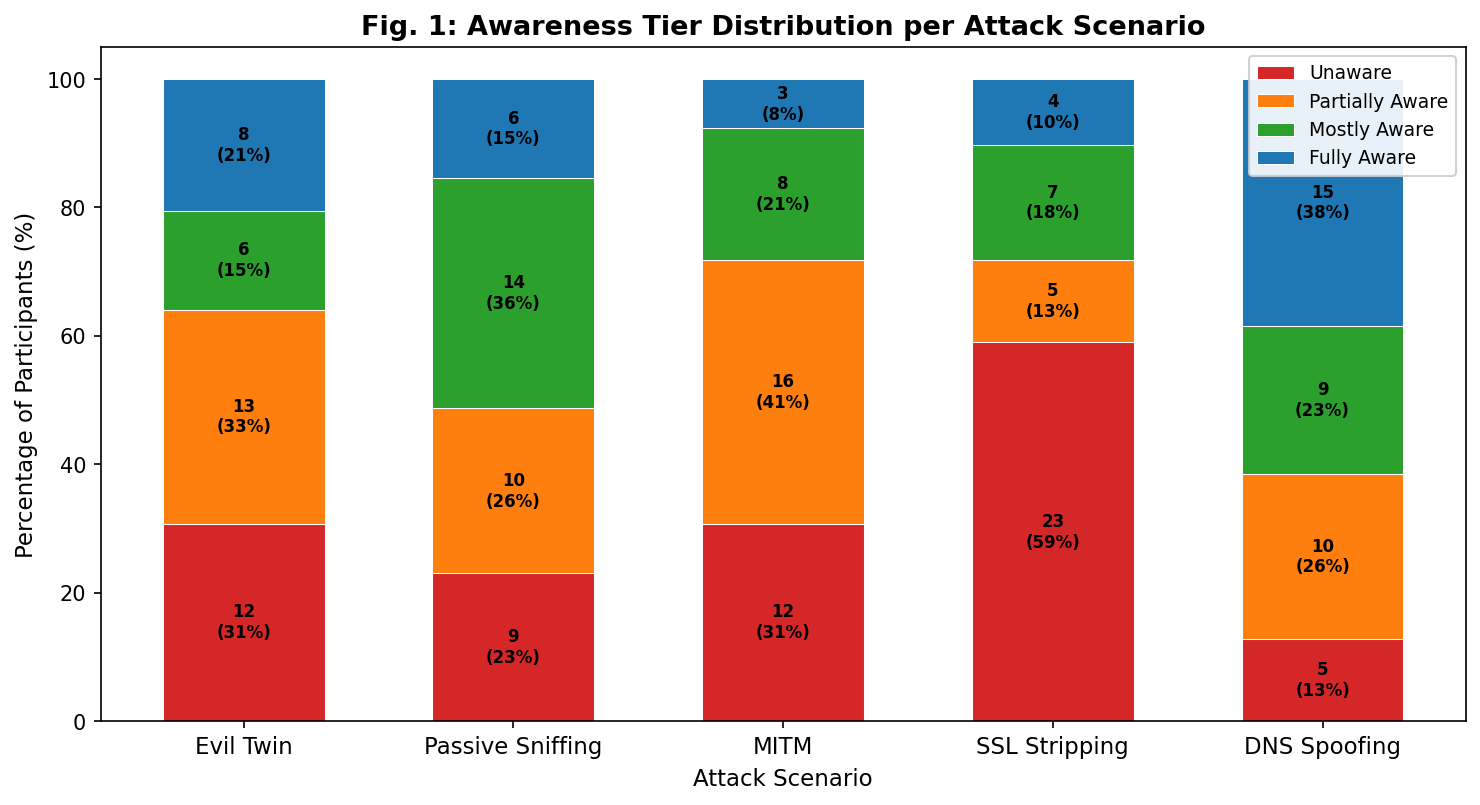

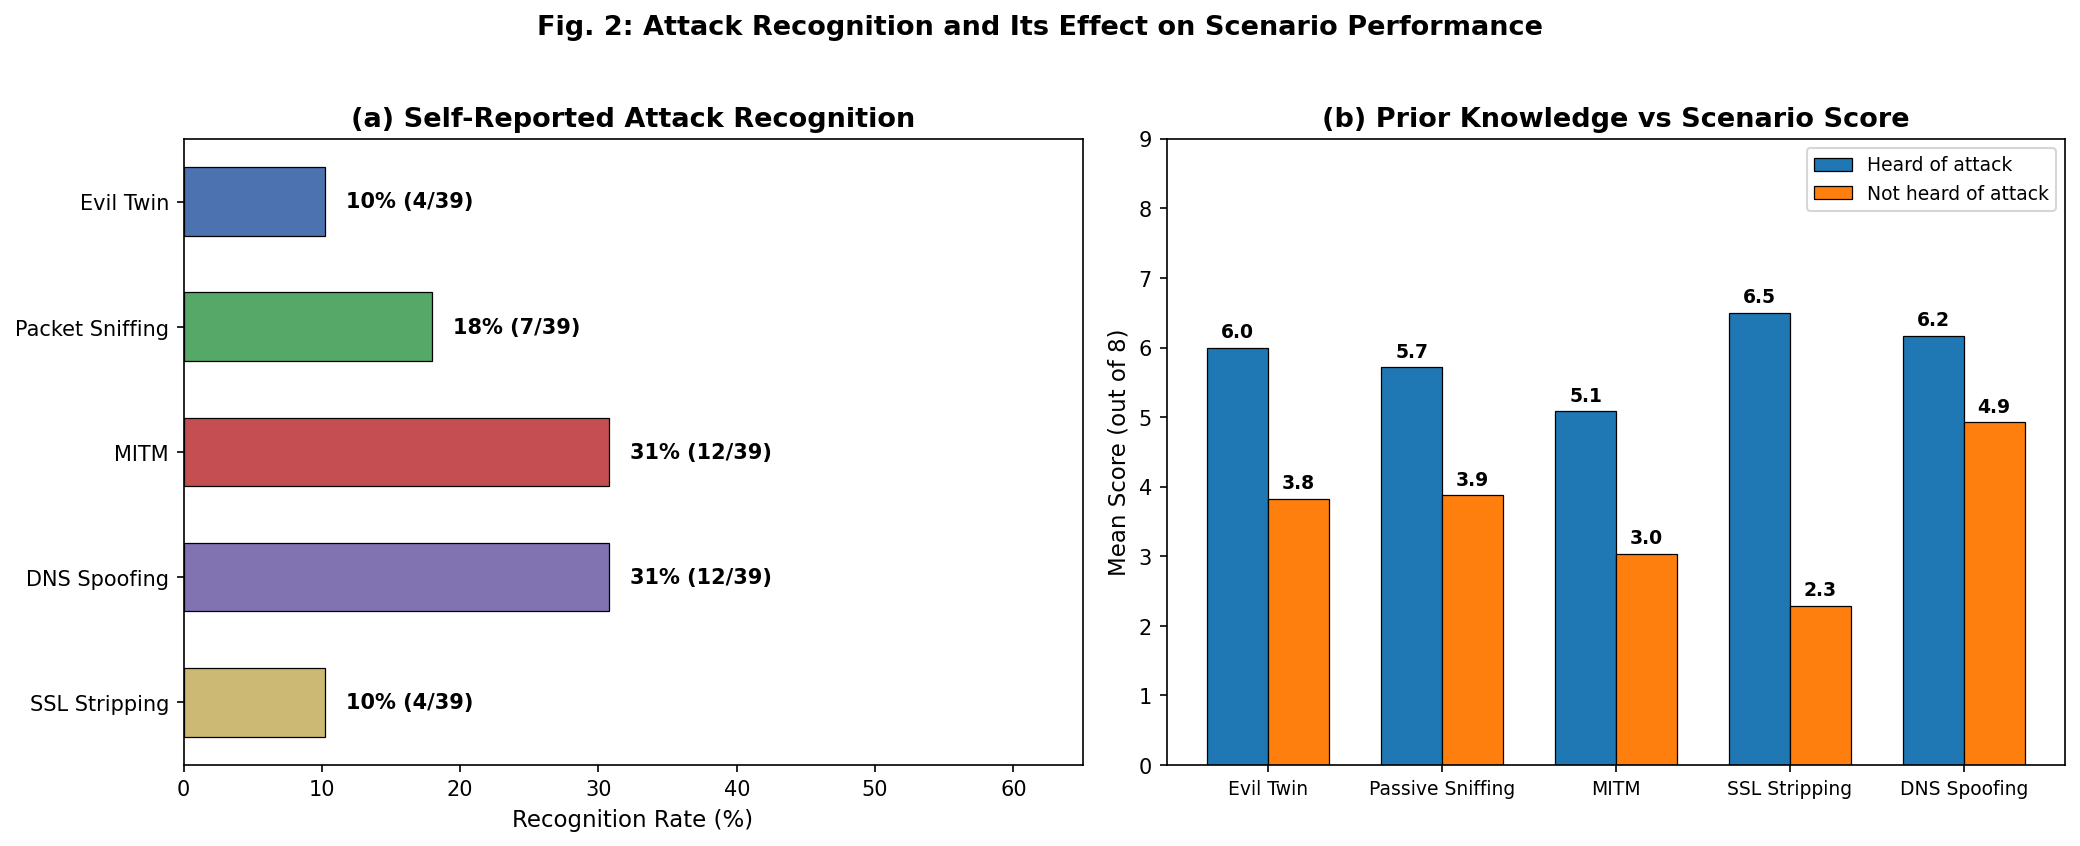

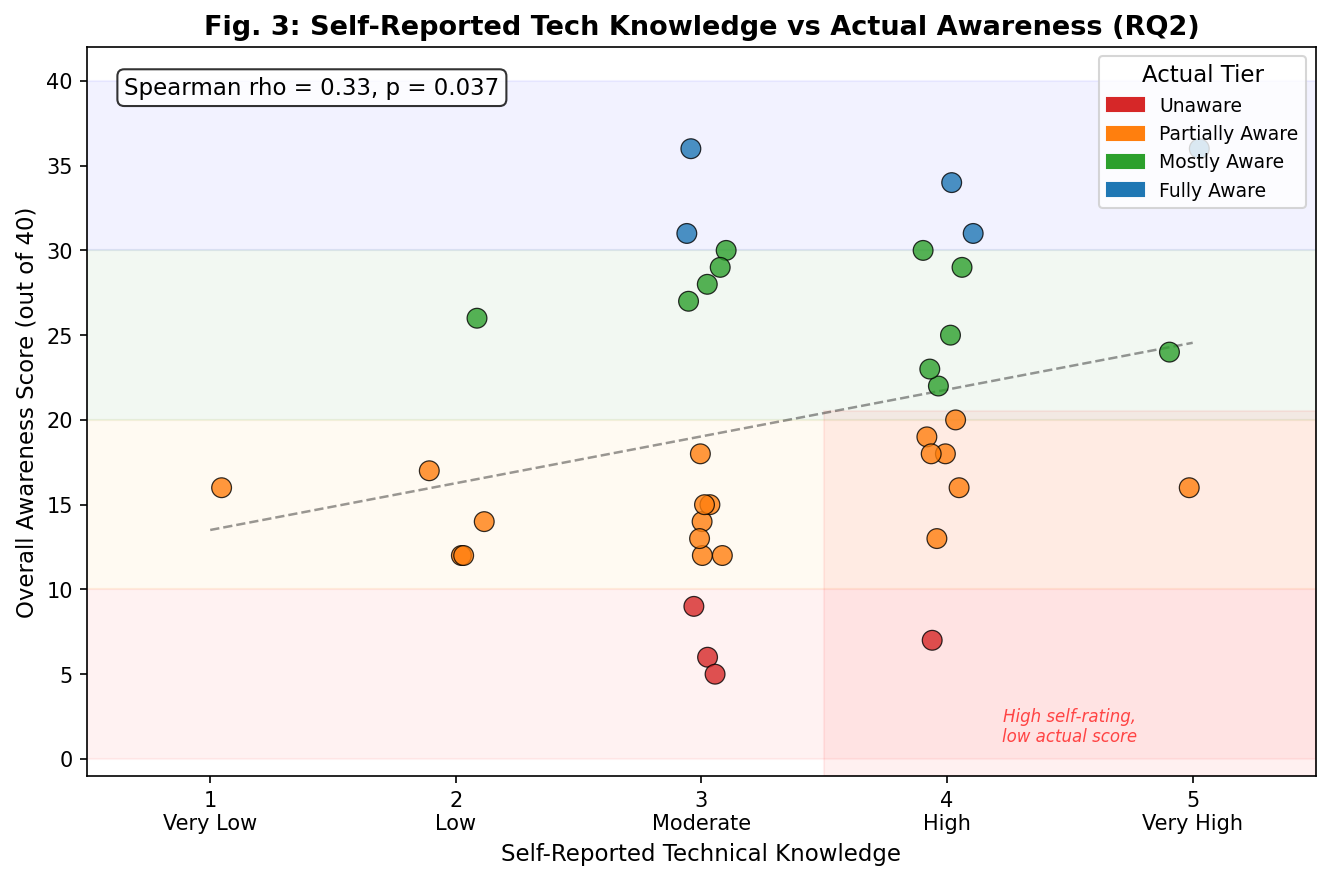

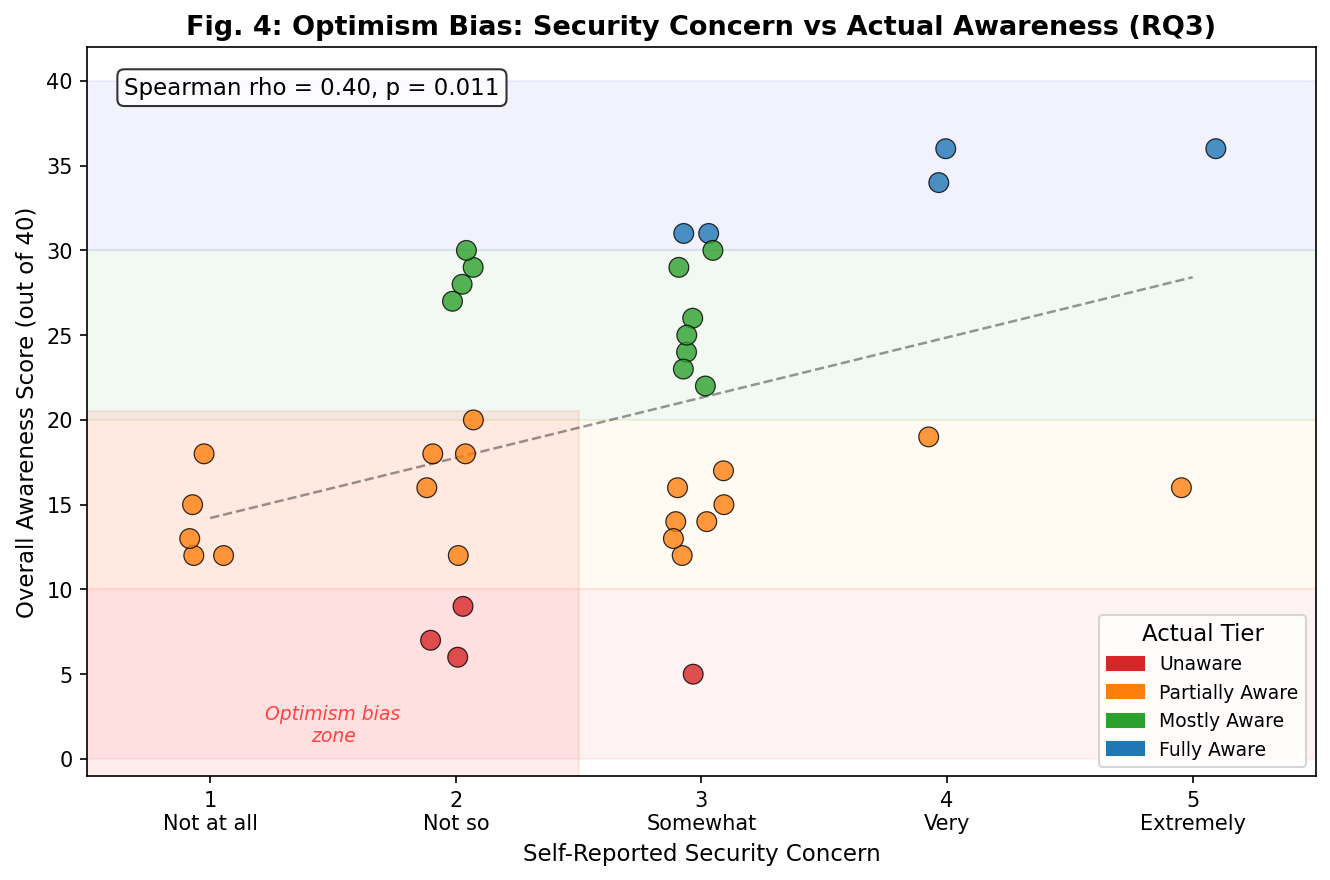

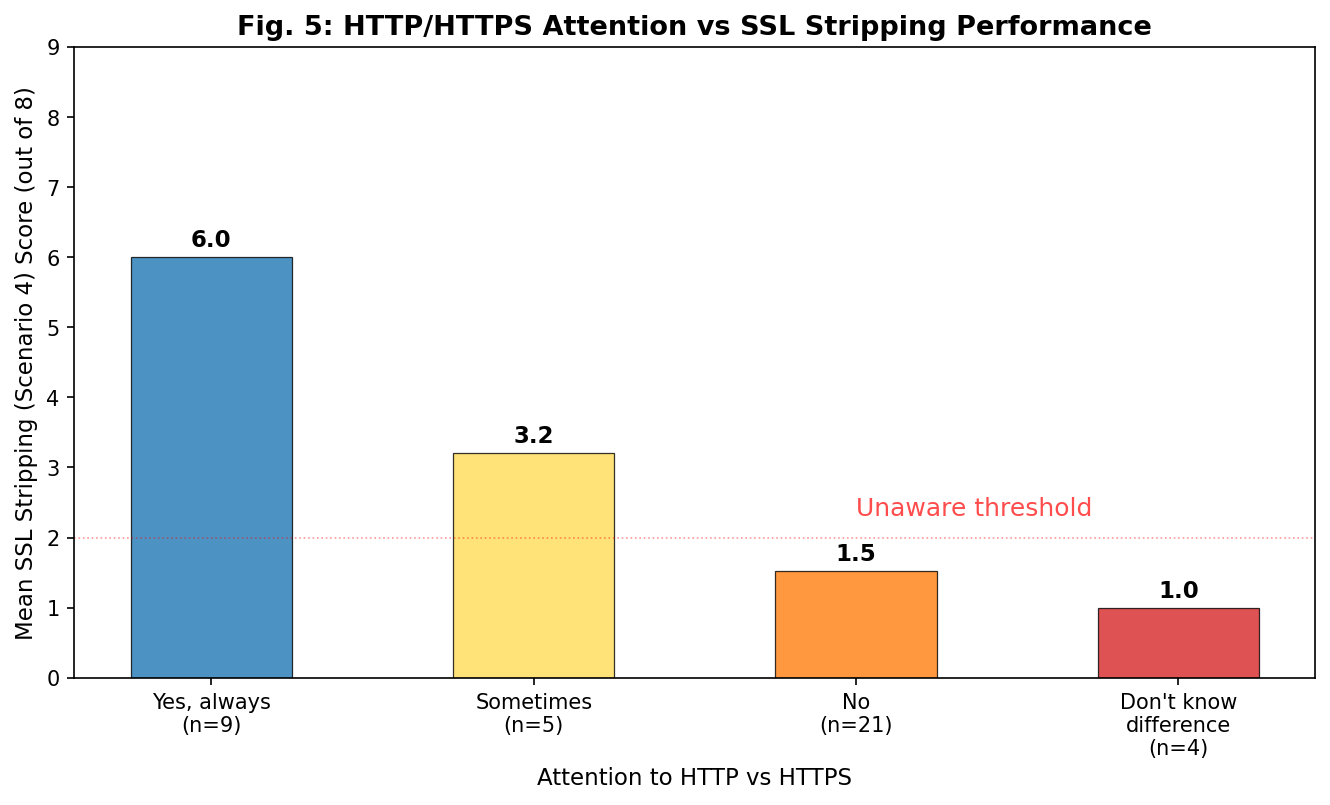

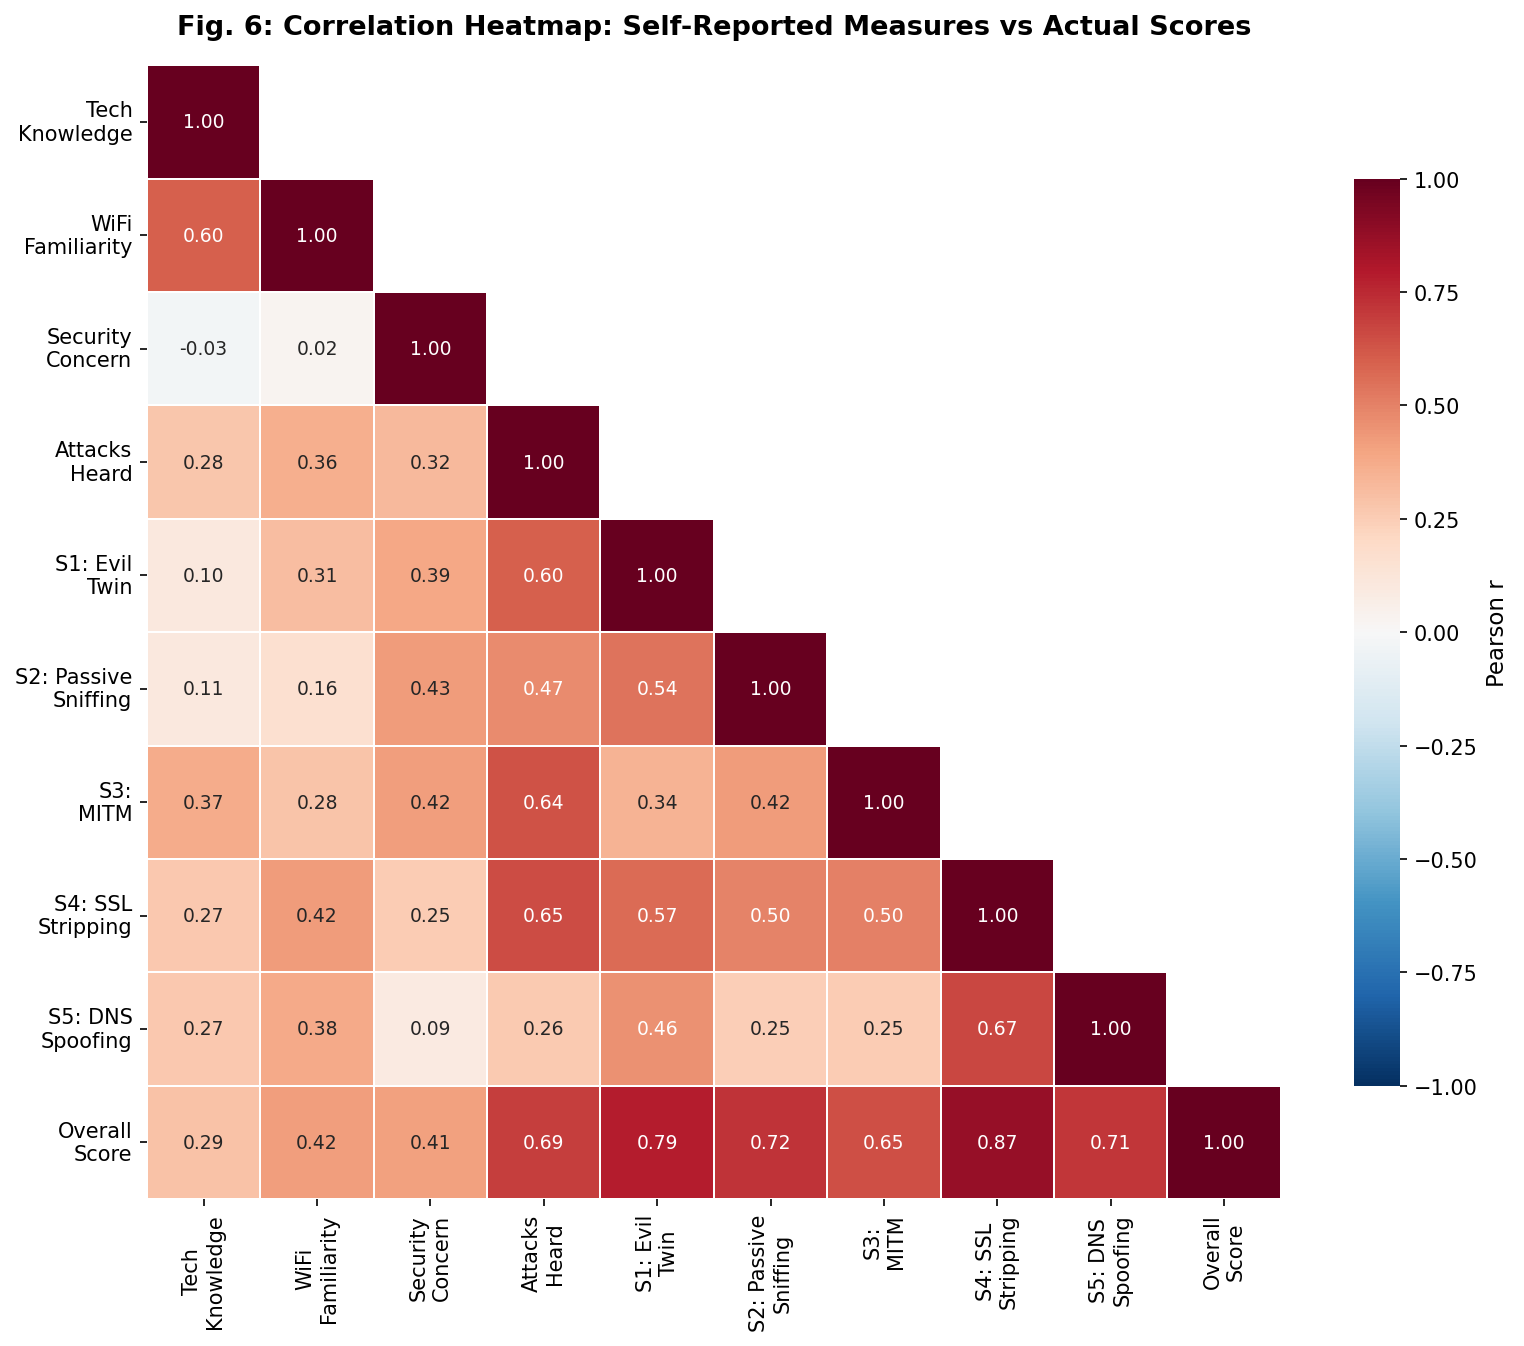

In [25]:
# fig 1 RQ1 per-scenario tier distribution

fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(scenario_names))
width = 0.6
bottom = np.zeros(len(scenario_names))

for tier in TIER_ORDER:
    counts = np.array([(df[f'{s}_Tier'] == tier).sum() for s in scenario_names])
    pcts = counts / len(df) * 100
    bars = ax.bar(x, pcts, width, bottom=bottom, label=tier, color=TIER_COLORS[tier],
                  edgecolor='white', linewidth=0.5)
    for i, (c, p, b) in enumerate(zip(counts, pcts, bottom)):
        if p > 5:
            ax.text(i, b + p/2, f'{c}\n({p:.0f}%)', ha='center', va='center',
                    fontsize=8, fontweight='bold')
    bottom += pcts

ax.set_xticks(x)
ax.set_xticklabels(list(scenario_names.values()), fontsize=11)
ax.set_ylabel('Percentage of Participants (%)')
ax.set_xlabel('Attack Scenario')
ax.set_title('Fig. 1: Awareness Tier Distribution per Attack Scenario', fontweight='bold')
ax.set_ylim(0, 105)
ax.legend(loc='upper right', framealpha=0.9, fontsize=9)
plt.tight_layout()
save_fig(fig, 'fig1_scenario_tier_distribution')


# fig 2 RQ

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

attack_names_list = ['Evil Twin', 'Packet Sniffing', 'MITM', 'DNS Spoofing', 'SSL Stripping']
heard_cols_list = ['Heard_EvilTwin', 'Heard_Sniffing', 'Heard_MITM', 'Heard_DNS', 'Heard_SSL']
recognition_rates = [df[c].sum() / len(df) * 100 for c in heard_cols_list]

y_pos = np.arange(len(attack_names_list))
bars = axes[0].barh(y_pos, recognition_rates, color=SCENARIO_COLORS, edgecolor='black',
                     linewidth=0.6, height=0.55)
for bar, rate, col in zip(bars, recognition_rates, heard_cols_list):
    count = df[col].sum()
    axes[0].text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2,
                 f'{rate:.0f}% ({count}/{len(df)})', va='center', fontsize=10, fontweight='bold')
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(attack_names_list)
axes[0].set_xlabel('Recognition Rate (%)')
axes[0].set_xlim(0, 65)
axes[0].set_title('(a) Self-Reported Attack Recognition', fontweight='bold')
axes[0].invert_yaxis()

x2 = np.arange(len(attack_scenario_map))
w = 0.35
heard_means = []
not_heard_means = []
names_list = []
for heard_col, (score_col, name) in attack_scenario_map.items():
    h = df[df[heard_col] == True][score_col]
    nh = df[df[heard_col] == False][score_col]
    heard_means.append(h.mean() if len(h) > 0 else 0)
    not_heard_means.append(nh.mean() if len(nh) > 0 else 0)
    names_list.append(name)

b1 = axes[1].bar(x2 - w/2, heard_means, w, label='Heard of attack', color='#1f77b4',
                  edgecolor='black', linewidth=0.6)
b2 = axes[1].bar(x2 + w/2, not_heard_means, w, label='Not heard of attack', color='#ff7f0e',
                  edgecolor='black', linewidth=0.6)
for bars_group in [b1, b2]:
    for bar in bars_group:
        if bar.get_height() > 0:
            axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
                         f'{bar.get_height():.1f}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(names_list, fontsize=9)
axes[1].set_ylabel('Mean Score (out of 8)')
axes[1].set_ylim(0, 9)
axes[1].set_title('(b) Prior Knowledge vs Scenario Score', fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Fig. 2: Attack Recognition and Its Effect on Scenario Performance',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
save_fig(fig, 'fig2_recognition_and_performance')


# fig 3 RQ2 self-reported tech knowledge vs actual score

fig, ax = plt.subplots(figsize=(9, 6))
jitter_x = df['Tech_Knowledge'] + np.random.uniform(-0.12, 0.12, len(df))
colors = [TIER_COLORS[t] for t in df['Overall_Tier']]
ax.scatter(jitter_x, df['Overall_Score'], s=90, alpha=0.8, edgecolors='black',
           linewidths=0.6, c=colors, zorder=3)

z = np.polyfit(df['Tech_Knowledge'].dropna(), df.loc[df['Tech_Knowledge'].notna(), 'Overall_Score'], 1)
xline = np.linspace(1, 5, 50)
ax.plot(xline, np.polyval(z, xline), 'k--', alpha=0.4, linewidth=1.2)

rho, p = stats.spearmanr(df['Tech_Knowledge'].dropna(), df.loc[df['Tech_Knowledge'].notna(), 'Overall_Score'])
ax.text(0.03, 0.96, f'Spearman rho = {rho:.2f}, p = {p:.3f}',
        transform=ax.transAxes, fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

ax.set_xlabel('Self-Reported Technical Knowledge')
ax.set_ylabel('Overall Awareness Score (out of 40)')
ax.set_title('Fig. 3: Self-Reported Tech Knowledge vs Actual Awareness (RQ2)', fontweight='bold')
ax.set_xlim(0.5, 5.5)
ax.set_ylim(-1, 42)
ax.axhspan(0, 10, alpha=0.05, color='red')
ax.axhspan(10, 20, alpha=0.05, color='orange')
ax.axhspan(20, 30, alpha=0.05, color='green')
ax.axhspan(30, 40, alpha=0.05, color='blue')
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xticklabels(['1\nVery Low', '2\nLow', '3\nModerate', '4\nHigh', '5\nVery High'])
ax.axvspan(3.5, 5.5, ymin=0, ymax=0.5, alpha=0.06, color='red')
ax.text(4.5, 1, 'High self-rating,\nlow actual score', ha='center', fontsize=8, color='red', fontstyle='italic', alpha=0.7)

patches = [mpatches.Patch(color=TIER_COLORS[t], label=t) for t in TIER_ORDER]
#ax.legend(handles=patches, loc='lower right', fontsize=9, title='Actual Tier')
ax.legend(handles=patches, loc='upper right', fontsize=9, title='Actual Tier')
plt.tight_layout()
save_fig(fig, 'fig3_tech_knowledge_vs_score')


# fig 4 RQ3 optimism bias

fig, ax = plt.subplots(figsize=(9, 6))
jitter_x = df['Security_Concern'] + np.random.uniform(-0.12, 0.12, len(df))
colors = [TIER_COLORS[t] for t in df['Overall_Tier']]
ax.scatter(jitter_x, df['Overall_Score'], s=90, alpha=0.8, edgecolors='black',
           linewidths=0.6, c=colors, zorder=3)

z = np.polyfit(df['Security_Concern'].dropna(), df.loc[df['Security_Concern'].notna(), 'Overall_Score'], 1)
xline = np.linspace(1, 5, 50)
ax.plot(xline, np.polyval(z, xline), 'k--', alpha=0.4, linewidth=1.2)

rho, p = stats.spearmanr(df['Security_Concern'].dropna(), df.loc[df['Security_Concern'].notna(), 'Overall_Score'])
ax.text(0.03, 0.96, f'Spearman rho = {rho:.2f}, p = {p:.3f}',
        transform=ax.transAxes, fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

ax.set_xlabel('Self-Reported Security Concern')
ax.set_ylabel('Overall Awareness Score (out of 40)')
ax.set_title('Fig. 4: Optimism Bias: Security Concern vs Actual Awareness (RQ3)', fontweight='bold')
ax.set_xlim(0.5, 5.5)
ax.set_ylim(-1, 42)
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xticklabels(['1\nNot at all', '2\nNot so', '3\nSomewhat', '4\nVery', '5\nExtremely'])
ax.axvspan(0.5, 2.5, ymin=0, ymax=0.5, alpha=0.07, color='red')
ax.text(1.5, 1, 'Optimism bias\nzone', ha='center', fontsize=9, color='red',
        fontstyle='italic', alpha=0.7)
ax.axhspan(0, 10, alpha=0.05, color='red')
ax.axhspan(10, 20, alpha=0.05, color='orange')
ax.axhspan(20, 30, alpha=0.05, color='green')
ax.axhspan(30, 40, alpha=0.05, color='blue')

patches = [mpatches.Patch(color=TIER_COLORS[t], label=t) for t in TIER_ORDER]
ax.legend(handles=patches, loc='lower right', fontsize=9, title='Actual Tier')
plt.tight_layout()
save_fig(fig, 'fig4_optimism_bias')


# fig 5 RQ1 HTTP/HTTPS attention & SSL stripping

fig, ax = plt.subplots(figsize=(9, 5.5))
http_order = ['Yes', 'Sometimes', 'No', "Don't know difference"]
http_short = ['Yes, always', 'Sometimes', 'No', "Don't know\ndifference"]
http_means = []
http_labels = []
http_colors = ['#1f77b4', '#ffdd57', '#ff7f0e', '#d62728']

for att, short in zip(http_order, http_short):
    subset = df[df['HTTP_Attention'] == att]
    if len(subset) > 0:
        http_means.append(subset['S4_Total'].mean())
        http_labels.append(f'{short}\n(n={len(subset)})')

bars = ax.bar(http_labels, http_means, color=http_colors[:len(http_means)],
              edgecolor='black', linewidth=0.6, alpha=0.8, width=0.5)
for bar, val in zip(bars, http_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
            f'{val:.1f}', ha='center', fontweight='bold')

ax.set_ylabel('Mean SSL Stripping (Scenario 4) Score (out of 8)')
ax.set_xlabel('Attention to HTTP vs HTTPS')
ax.set_title('Fig. 5: HTTP/HTTPS Attention vs SSL Stripping Performance', fontweight='bold')
ax.set_ylim(0, 9)
ax.axhline(y=2, color='red', linestyle=':', alpha=0.4, linewidth=0.8)
ax.text(2, 2.25, 'Unaware threshold', fontsize=12, color='red', alpha=0.7, ha='left', va='bottom')
plt.tight_layout()
save_fig(fig, 'fig5_https_attention_ssl_stripping')


# fig 6 heatmap

corr_cols = ['Tech_Knowledge', 'WiFi_Familiarity', 'Security_Concern',
             'Attacks_Heard_Count', 'S1_Total', 'S2_Total', 'S3_Total',
             'S4_Total', 'S5_Total', 'Overall_Score']
corr_labels = ['Tech\nKnowledge', 'WiFi\nFamiliarity', 'Security\nConcern',
               'Attacks\nHeard', 'S1: Evil\nTwin', 'S2: Passive\nSniffing',
               'S3:\nMITM', 'S4: SSL\nStripping', 'S5: DNS\nSpoofing', 'Overall\nScore']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, center=0, square=True,
            linewidths=0.8, linecolor='white',
            xticklabels=corr_labels, yticklabels=corr_labels,
            cbar_kws={'label': 'Pearson r', 'shrink': 0.8},
            annot_kws={'fontsize': 9}, ax=ax)
ax.set_title('Fig. 6: Correlation Heatmap: Self-Reported Measures vs Actual Scores',
             fontweight='bold', pad=15)
plt.tight_layout()
save_fig(fig, 'fig6_correlation_heatmap')

